In [38]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import sympy as sp
from sympy.plotting import plot
from matplotlib import pyplot as plt
import sys
from scipy.integrate import solve_ivp
import seaborn as sns
from numpy import meshgrid , arange , full , linalg
x,t = sp.symbols('x t')
x,t = sp.symbols('x t')

# Raízes de equações

## Bracketing Methods

Métodos Gráficos

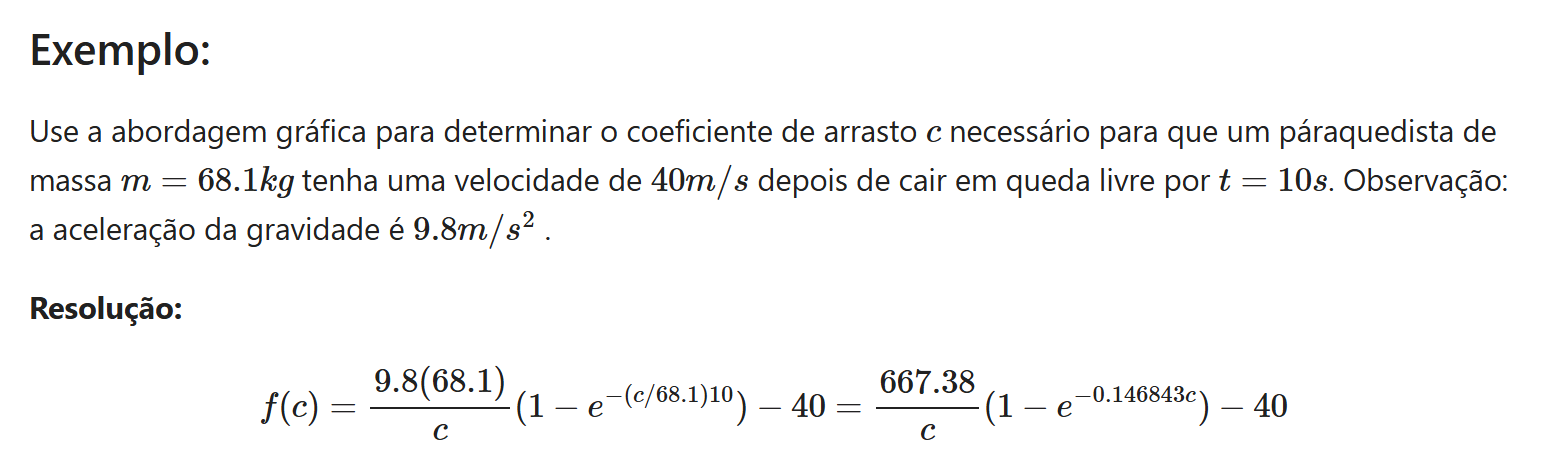

In [39]:
c = np.linspace(1,30, 100)
f = lambda c: (667.38/c)*(1 - np.exp(-0.146843*c)) - 40
f_c = f(c)

In [40]:
fig = make_subplots(rows=1, cols=3)

fig.add_scatter(x=c, y=f_c, row=1, col=1)
fig.update_xaxes(title_text="Intervalo completo", range=[1, 30], row=1, col=1)

fig.add_scatter(x=c, y=f_c, row=1, col=2)
fig.update_xaxes(title_text="Zoomando", range=[13, 16], row=1, col=2)

fig.add_scatter(x=c, y=f_c, row=1, col=3)
fig.update_xaxes(title_text="Zoomando mais", range=[14.5, 15], row=1, col=3)


fig.update_layout(height=600, width=800, title_text="Metodo Gráfico", showlegend=False)

Olhando para o grafico podemos testar alguns valores para aproximar a raiz



In [41]:
t_test = np.linspace(14.5, 15, 11)

for point in t_test: 
    print(f'No ponto c= {point} o valor da função é {f(point)}')

No ponto c= 14.5 o valor da função é 0.5523282056876297
No ponto c= 14.55 o valor da função é 0.45287837983074297
No ponto c= 14.6 o valor da função é 0.35381879948397454
No ponto c= 14.65 o valor da função é 0.2551475898353459
No ponto c= 14.7 o valor da função é 0.15686288611858146
No ponto c= 14.75 o valor da função é 0.058962833555469274
No ponto c= 14.8 o valor da função é -0.038554412701259366
No ponto c= 14.85 o valor da função é -0.13569068762480896
No ponto c= 14.9 o valor da função é -0.23244781637085055
No ponto c= 14.95 o valor da função é -0.3288276143336546
No ponto c= 15.0 o valor da função é -0.4248318872019681


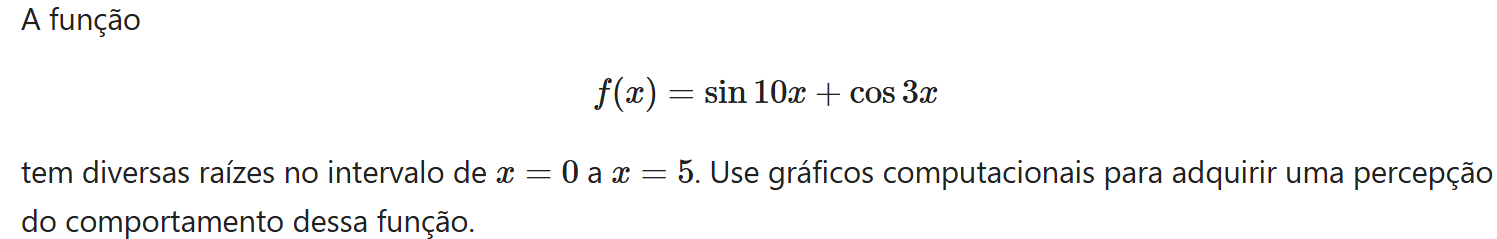

In [42]:
x = np.linspace(0,5, 500)
f = lambda x: np.sin(10*x) + np.cos(3*x)
f_x = f(x)

In [43]:
fig = make_subplots(rows=1, cols=3)

fig.add_scatter(x=x, y=f_x, row=1, col=1)
fig.update_xaxes(title_text="Intervalo completo", 
                range=[0, 5], row=1, col=1)

fig.add_scatter(x=x, y=f_x, row=1, col=2)
fig.update_xaxes(title_text="Zoomando", range=[3, 5], row=1, col=2)

fig.add_scatter(x=x, y=f_x, row=1, col=3)
fig.update_xaxes(title_text="Zoomando mais", range=[4.2, 4.3], row=1, col=3)


fig.update_layout(height=600, width=800, title_text="Metodo Gráfico", showlegend=False)

Método da Bissecção

In [44]:
def bisection_minimal(func, xl, xu, max_iter=5):

    for i in range(max_iter):
        
        xr = (xl + xu)/2
        print(xr)
        f_xr = func(xr)
        f_xl = func(xl)
        if f_xl * f_xr < 0:
            xu = xr
        elif f_xl * f_xr > 0:
            xl = xr
        else:
            return xr
            
    return xr

In [45]:
f = lambda x: (667.38/x)*(1 - np.exp(-0.146843*x)) - 40

In [46]:
bisection_minimal(f, 12, 16)

14.0
15.0
14.5
14.75
14.875


14.875

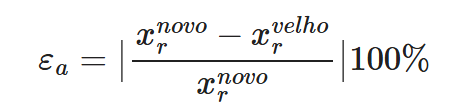

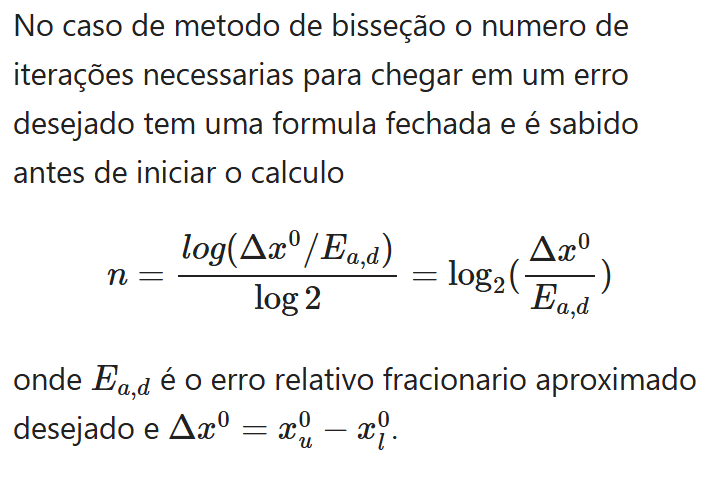

In [47]:
def bisection(func, xl, xu, tol=1e-3, max_iter=100):
    assert func(xu) * func(xl) < 0, 'func(xu) * func(xl) must be a negative value'

    iteration = 0
    error = abs((xu-xl)/xu) * 100
    xr = (xl + xu)/2 + 0.1 * (xl + xu)/2

    while error > tol and iteration < max_iter:
        xr_old = xr
        xr = (xl + xu)/2
        
        f_xr = func(xr)
        f_xl = func(xl)

        if f_xl * f_xr < 0:
            xu = xr
        elif f_xl * f_xr > 0:
            xl = xr
        else:
            return xr
            
        error = abs((xr-xr_old)/xr) * 100
        print('xr', xr, 'error', error)

        iteration += 1

    return xr

In [48]:
bisection(f, 12, 16, tol=5e-1, max_iter=100)

xr 14.0 error 10.000000000000002
xr 15.0 error 6.666666666666667
xr 14.5 error 3.4482758620689653
xr 14.75 error 1.694915254237288
xr 14.875 error 0.8403361344537815
xr 14.8125 error 0.42194092827004215


14.8125

Método da falsa posição

In [49]:
def false_position_minimal(func, xl, xu, max_iter=5):
    for i in range(max_iter):
        f_xu = func(xu)
        f_xl = func(xl)
        xr = xu - (f_xu*(xl-xu))/(f_xl - f_xu)
        print('xr is: ', xr)
        if func(xr) * f_xu > 0:
            xu = xr
        elif func(xr) * f_xu < 0:
            xl = xr
        else:
            return xr
    
    return xr

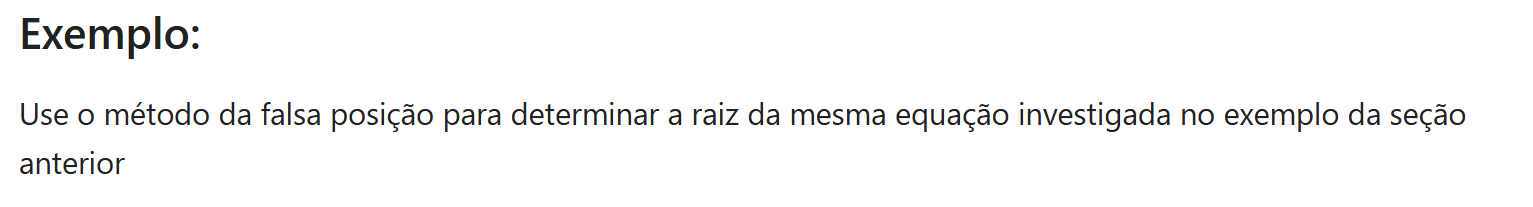

In [50]:
f = lambda x: (667.38/x)*(1 - np.exp(-0.146843*x)) - 40

false_position_minimal(f, 12, 16, max_iter=10)

xr is:  14.911307713658712
xr is:  14.794197551807244
xr is:  14.781700103915494
xr is:  14.78036760579795
xr is:  14.780225546043724
xr is:  14.780210400978051
xr is:  14.780208786356297
xr is:  14.780208614220825
xr is:  14.780208595869388
xr is:  14.780208593912937


np.float64(14.780208593912937)

Armadilhas do Método da Falsa Posição

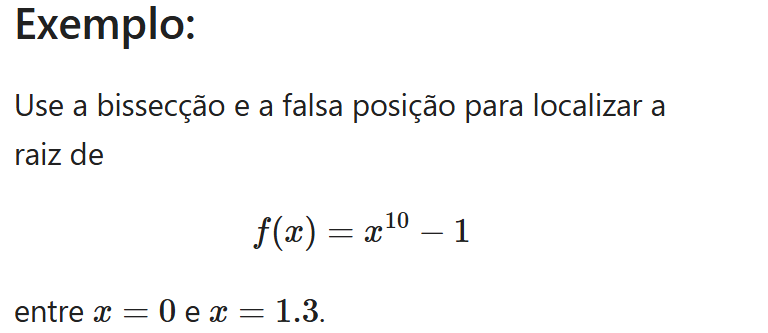

In [51]:
f1 = lambda x: x**10 -1

In [52]:
# usando o metodo de bisseção minimalista temos 

bisection_minimal(f1, 0, 1.3, max_iter=5)

0.65
0.9750000000000001
1.1375000000000002
1.0562500000000001
1.015625


1.015625

In [53]:
#usando o metodo de falsa posição temos 

false_position_minimal(f1, 0, 1.3, max_iter=5)


xr is:  0.09429959537232735
xr is:  0.1817588725190793
xr is:  0.2628740125203042
xr is:  0.3381051033222693
xr is:  0.4078779165927523


0.4078779165927523

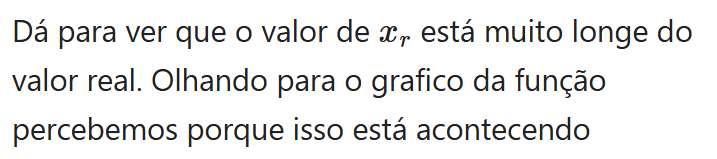

In [54]:
def false_position_minimal_return(func, xl, xu, max_iter=5):
    xrs = []
    for i in range(max_iter):
        f_xu = func(xu)
        f_xl = func(xl)
        xr = xu - (f_xu*(xl-xu))/(f_xl - f_xu)
        xrs.append(xr)
        if func(xr) * f_xu > 0:
            xu = xr
        elif func(xr) * f_xu < 0:
            xl = xr
        else:
            return xr

    return xrs

def bisection_minimal_return(func, xl, xu, max_iter=5):
    xrs = []
    for i in range(max_iter):
        
        xr = (xl + xu)/2
        xrs.append(xr)
        f_xr = func(xr)
        f_xl = func(xl)
        if f_xl * f_xr < 0:
            xu = xr
        elif f_xl * f_xr > 0:
            xl = xr
        else:
            return xrs
            
    return xrs

xrs_false = false_position_minimal_return(f1, 0, 1.3, max_iter=10)
xrs_false = np.array(xrs_false)

xrs_bissection = bisection_minimal_return(f1, 0, 1.3, max_iter=10)
xrs_bissection = np.array(xrs_bissection)

x = np.linspace(0,2, 50)
f_x = f1(x)
fig = go.Figure()
fig.add_scatter(x=x, y=f_x, name='x^10-1')
fig.add_scatter(x = xrs_bissection, y=f1(xrs_bissection), mode='markers', name='bissection')
fig.add_scatter(x = xrs_false, y=f1(xrs_false), mode='markers', name='false position')



O exemplo anterior ilustra que generalizações abrangentes com relação aos métodos de localização de raízes, em geral, não são possíveis. Embora um método como a falsa posição seja quase sempre superior à bissecção, invariavelmente há casos que violam essas conclusões gerais. Portanto, além de se usar a aproximação de erro, os resultados deveriam sempre ser verificados substituindo a estimativa da raiz na equação original e verificando se o resultado está próximo a zero. Tal verificação deveria ser incorporada em todos os programas de computador para a localização de raízes. O exemplo também ilustra uma grande fraqueza do método da falsa posição: ele é unilateral. Ou seja, conforme as iterações continuam, uma das extremidades do intervalo terá a tendência de permanecer fixa. Isso pode levar à convergência insatisfatória, particularmente para funções com curvatura significativa.

O Metodo da Falsa Posição Modificada

In [55]:
def false_position(func, xl, xu, tolerance=1e-3, max_iter=100):
    iteration = 0
    iu= il = 0
    error = abs((xu-xl)/xu) * 100
    xr = (xl + xu)/2 + 0.1 * (xl + xu)/2
    f_xu = func(xu)
    f_xl = func(xl)
    while error > tolerance and iteration < max_iter:
        
        
        xr_old = xr
        xr = xu - (f_xu*(xl-xu))/(f_xl - f_xu)
        f_xr = func(xr)

        test = f_xr * f_xl

        if test < 0:
            xu = xr
            f_xu = func(xu)
            iu = 0
            il = il + 1
            if il >= 2: 
                f_xl /= 2
        elif test > 0:
            xl = xr
            f_xl = func(xl)
            il = 0
            iu = iu + 1
            if iu >=2:
                f_xu /= 2
        else:
            return xr
        
        error = abs((xr-xr_old)/xr) * 100
        print('xr', xr, 'error', error)

        iteration += 1
    
    return xr

In [56]:
false_position(f1, 0, 1.3, max_iter=100)

xr 0.09429959537232735 error 658.2217051695009
xr 0.1817588725190793 error 48.11829867483983
xr 0.33301715676712107 error 45.42056803211995
xr 0.5634423147022628 error 40.89596253644958
xr 0.8463635731395354 error 33.42786332211735
xr 1.074910177068493 error 21.261925768742138
xr 0.9454923183277778 error 13.687880507544154
xr 0.9828011093189348 error 3.796168994661739
xr 1.0040954923602121 error 2.120752777330274
xr 0.9996755374546943 error 0.44213894808025606
xr 0.9999940615677148 error 0.03185260045655777
xr 1.0000057046332558 error 0.0011642999121982691
xr 0.9999999998475554 error 0.0005704785701258567


0.9999999998475554

In [57]:

bisection(f1, 0, 1.3, max_iter=100)

xr 0.65 error 10.000000000000009
xr 0.9750000000000001 error 33.333333333333336
xr 1.1375000000000002 error 14.28571428571429
xr 1.0562500000000001 error 7.692307692307695
xr 1.015625 error 4.000000000000013
xr 0.9953125 error 2.0408163265306074
xr 1.00546875 error 1.010101010100997
xr 1.000390625 error 0.5076142131979517
xr 0.9978515625000001 error 0.25445292620865356
xr 0.9991210937500001 error 0.12706480304956191
xr 0.9997558593750001 error 0.06349206349206127
xr 1.0000732421875 error 0.031735956839092035
xr 0.9999145507812501 error 0.015870496746539283
xr 0.9999938964843751 error 0.007934618741565026
xr 1.0000335693359377 error 0.003967151981601295
xr 1.0000137329101564 error 0.0019836153373182287
xr 1.0000038146972656 error 0.0009918175055922962


1.0000038146972656

## Métodos Abertos

Iteração de Ponto Fixo Simples

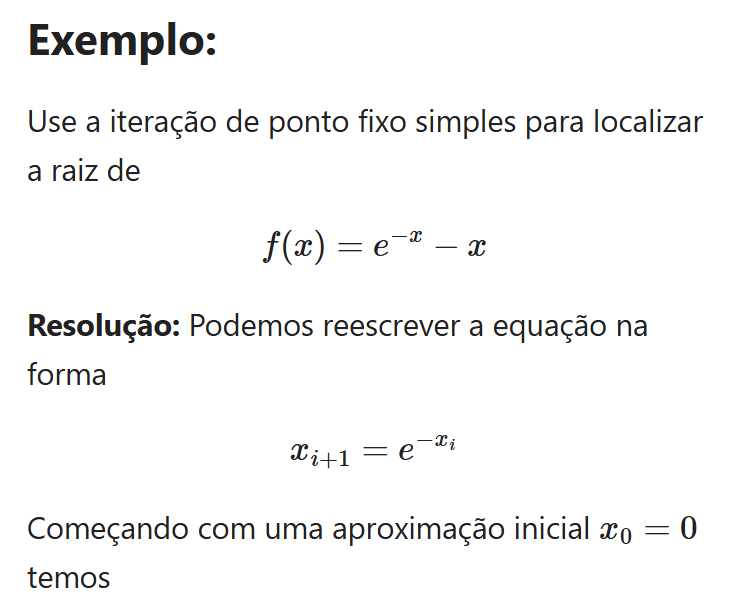

In [58]:
xi = 0
iteration = 10
for i in range(iteration):
    x_new = np.exp(-xi)
    erro = (x_new - xi)/x_new * 100
    print(f'x_new é {x_new} e o erro é {abs(erro)}')
    xi = x_new

x_new é 1.0 e o erro é 100.0
x_new é 0.36787944117144233 e o erro é 171.8281828459045
x_new é 0.6922006275553464 e o erro é 46.85363946133844
x_new é 0.5004735005636368 e o erro é 38.30914659333314
x_new é 0.6062435350855974 e o erro é 17.446789681151248
x_new é 0.545395785975027 e o erro é 11.156622525381316
x_new é 0.5796123355033789 e o erro é 5.9033508144086735
x_new é 0.5601154613610891 e o erro é 3.480866979624528
x_new é 0.571143115080177 e o erro é 1.9308039312598229
x_new é 0.5648793473910495 e o erro é 1.1088682420515694


In [59]:
xx = np.linspace(0,2,50)
f = lambda x: np.exp(-x) - x 
yy = f(xx)

fig = go.Figure()
fig.add_scatter(x=xx, y=yy)

-x + exp(-x)

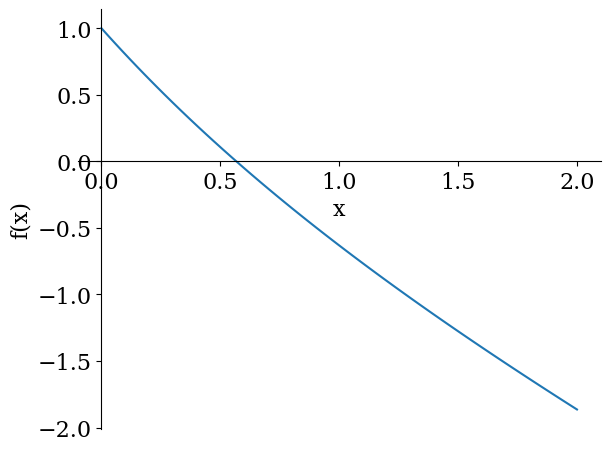

In [60]:
x = sp.symbols('x')
# Define the function
f = sp.exp(-x) -x
display(f)
plot(f, (x,0,2))
plt.show()

O Método de Newton-Raphson

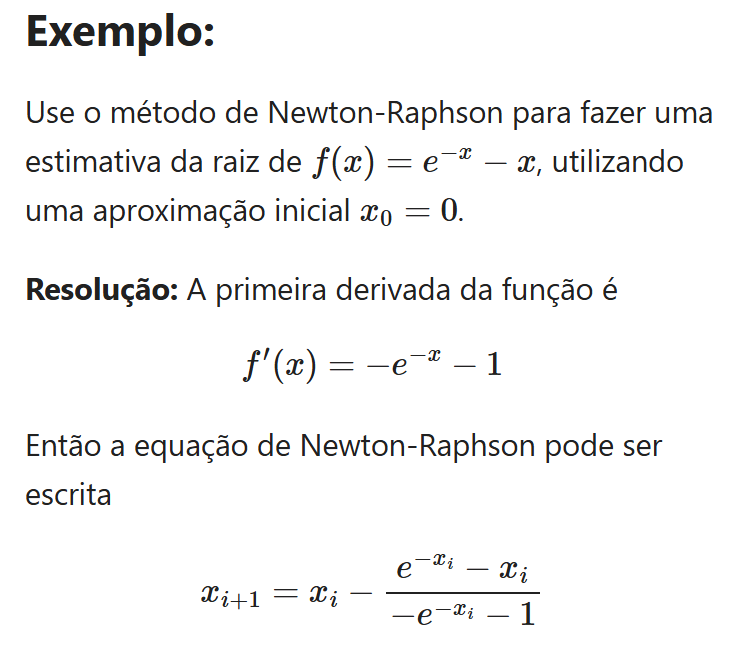

In [61]:
xi = 0
for i in range(5):
    xi -= (np.exp(-xi) - xi) / (-np.exp(-xi) - 1)
    print(xi) 

0.5
0.5663110031972182
0.5671431650348622
0.5671432904097811
0.567143290409784


In [62]:
def newtonRaphson(func, dfunc, xl, xu, tol=1.0e-3, max_iter=100):
    """
    Finds a root of f(x) = 0 by combining the Newton-Raphson
    method with bisection. The root must be bracketed in (a,b).
    Calls user-supplied functions f(x) and its derivative df(x).
    """
    f_xl = func(xl)
    f_xu = func(xu)

    assert f_xl * f_xu < 0,  'Root is not bracketed'

    x = 0.5*(xl + xu)
    error = 100
    iteration = 0

    while error > tol and iteration <= max_iter:
        f_x = func(x)

        # Tighten the brackets on the root
        if f_xl * f_x < 0:
            xu = x
        else:
            xl = x

        # Try a Newton-Raphson step
        df_x = dfunc(x)
        # If division by zero, push x out of bounds
        try: 
            dx = -f_x/df_x
        except ZeroDivisionError: 
            dx = xu - xl

        x_new = x + dx
        # If the result is outside the brackets, use bisection
        if (xu - x_new)*(x_new - xl) < 0.0:
            dx = 0.5*(xu - xl)
            x_new = xl + dx
        # Check for convergence
        error = abs((x_new - x)/x_new )* 100

        x = x_new
        iteration += 1

    return x_new, error

O Método da Secante


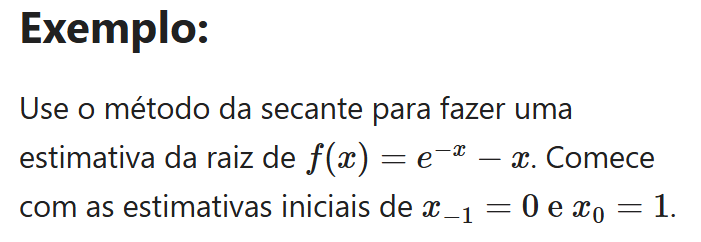

In [63]:
f = lambda x: np.exp(-x) - x
x0 = 0
x1 = 1

for i in range(5):
    x_new = x1 - (f(x1)*(x0 - x1))/(f(x0) - f(x1))
    error = abs((x_new - x1)/ x_new) * 100
    print(x_new, error)
    x0 = x1
    x1 = x_new  

0.6126998367802821 63.212055882855765
0.5638383891610742 8.665860388099505
0.5671703584197446 0.5874723897690938
0.5671433066049633 0.004769837617107992
0.5671432904097046 2.855584992987919e-06


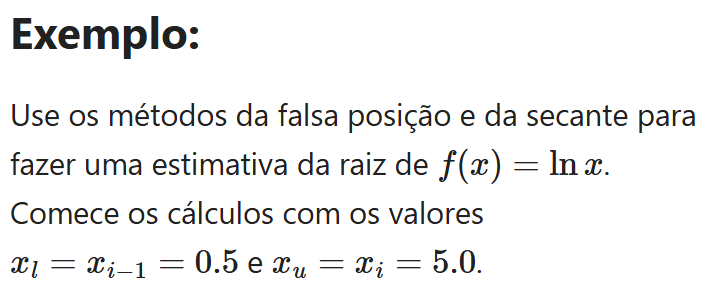

In [64]:
f = lambda x: np.log(x)

false_position(f, 0.5, 5, max_iter=3)

xr 1.8546349804879152 error 63.104871407320616
xr 1.216307818467517 error 52.480725054012765
xr 0.9576997708144797 error 27.003039525957384


np.float64(0.9576997708144797)

As estimativas para o metodo falsa-posição são convergindo mas para o metodo de secante estão divergindo.

In [65]:
x0 = 0.5
x1 = 5

for i in range(3):
    x_new = x1 - (f(x1)*(x0 - x1))/(f(x0) - f(x1))
    error = (x_new - x1)/ x_new * 100
    print(x_new, error)
    x0 = x1
    x1 = x_new  

1.8546349804879152 -169.59482877243076
-0.1043807923822424 1876.79718476963
nan nan


C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_21936\2004801066.py:1: RuntimeWarning:

invalid value encountered in log



Método da Secante Modificado

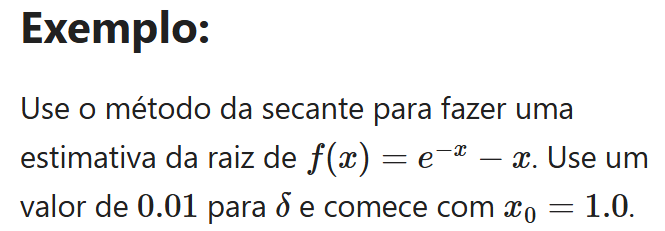

In [66]:
f = lambda x: np.exp(-x) - x
x0 = 1
delta = 0.01
for i in range(5):
    x_new = x0 - delta*f(x0)/(f(x0+delta) - f(x0))
    error = (x_new - x0)/ x_new * 100
    print(x_new, error)
    x0 = x_new 

0.5372626655366407 -86.12869721761844
0.5670349866351645 5.250526299125802
0.5671434839718879 0.019130491628593687
0.567143290060064 -3.4190975582167225e-05
0.5671432904104158 6.177482014462298e-08


Raízes Múltiplas

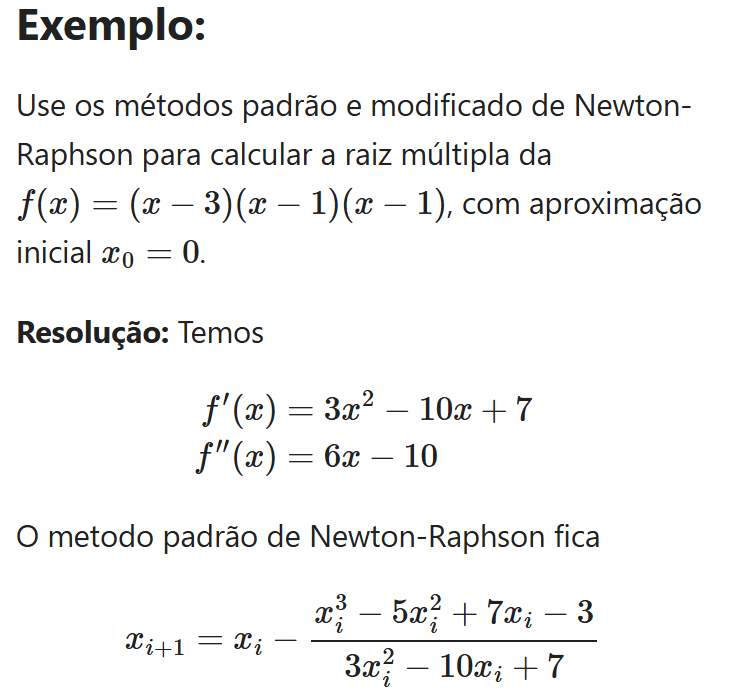

In [67]:
xi = 0
f = lambda x: x**3 - 5*x**2 + 7*x - 3
df = lambda x: 3*x**2 - 10*x +7
for i in range(5):
    x_new = xi - f(xi)/df(xi)
    error = ((x_new - xi)/x_new) *100
    print(x_new, error)
    xi = x_new 

0.42857142857142855 100.0
0.6857142857142857 37.50000000000001
0.8328654004954585 17.668054729327803
0.9133298932566344 8.810014142235714
0.955783292965739 4.441739044985216


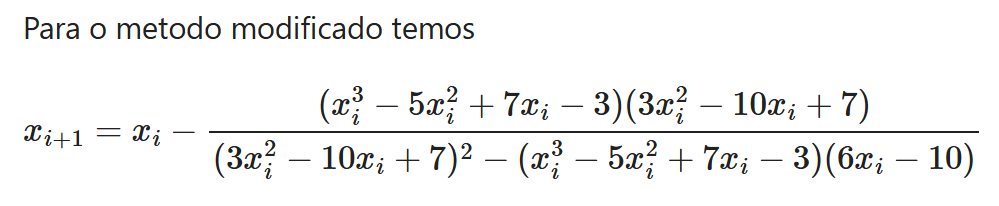

In [68]:
xi = 0
f = lambda x: x**3 - 5*x**2 + 7*x - 3
df = lambda x: 3*x**2 - 10*x +7
ddf = lambda x: 6*x - 10
for i in range(5):
    x_new = xi - (f(xi)*df(xi))/(df(xi)**2 - f(xi)*ddf(xi))
    error = abs(((x_new - xi)/x_new)) *100
    print(x_new, error)
    xi = x_new

1.105263157894737 100.0
1.0030816640986033 10.186757215620794
1.0000023814938155 0.3079275271512832
1.0000000000373122 0.00023814565032420238
1.0000000000746248 3.731259745342274e-09


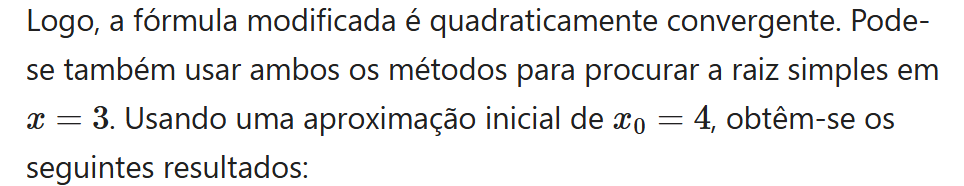

In [69]:
f = lambda x: x**3 - 5*x**2 + 7*x - 3
df = lambda x: 3*x**2 - 10*x +7
ddf = lambda x: 6*x - 10

display("Metodo Newton-Raphson Padrão")
xi = 4
for i in range(5):
    x_new = xi - f(xi)/df(xi)
    error = ((x_new - xi)/x_new) *100
    print(x_new, error)
    xi = x_new 

display("Metodo Newton-Raphson Modificado")
xi = 4
for i in range(5):
    x_new = xi - (f(xi)*df(xi))/(df(xi)**2 - f(xi)*ddf(xi))
    error = ((x_new - xi)/x_new) *100
    print(x_new, error)
    xi = x_new 

'Metodo Newton-Raphson Padrão'

3.4 -17.647058823529417
3.0999999999999996 -9.677419354838719
3.0086956521739134 -3.03468208092483
3.000074640791192 -0.2873598965007109
3.000000005570622 -0.002487840681033983


'Metodo Newton-Raphson Modificado'

2.6363636363636367 -51.72413793103446
2.820224719101124 6.519377037305328
2.9617282104948424 4.777733854588773
2.998478719188151 1.2256384698724412
2.9999976821826633 0.05063213893576597


## Sistemas de Equações Não-Lineares

Iteração de Ponto Fixo


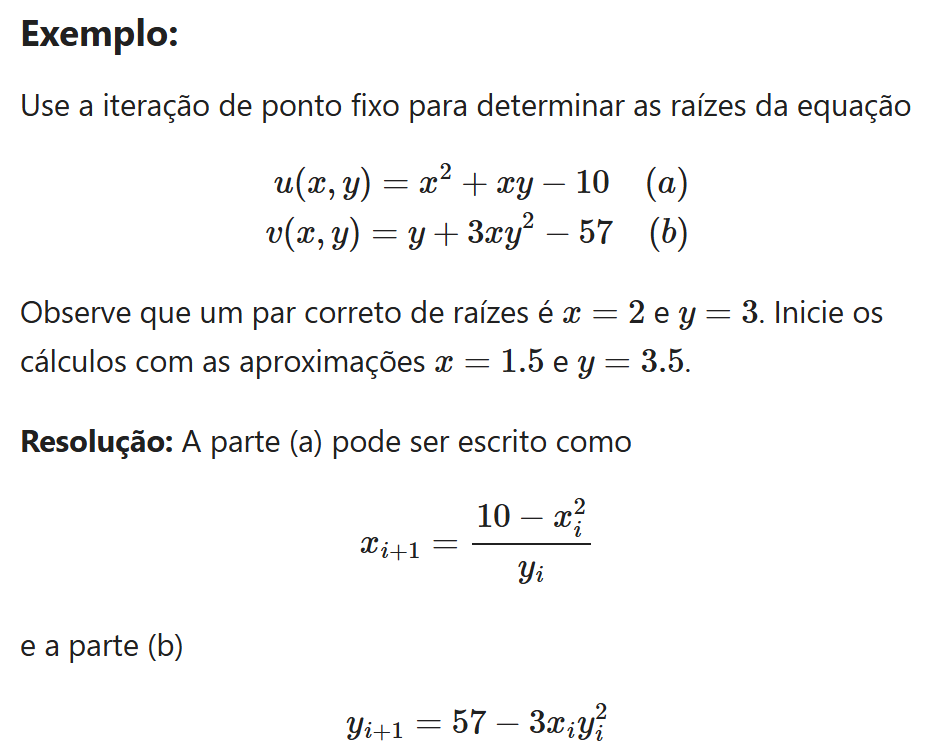

In [70]:
xi = 1.5
yi = 3.5
iteration = 5
for i in range(iteration):
    x_new = (10 - xi**2) / yi
    y_new = 57 - 3*x_new*yi**2 # x_new instead of xi
    erro_x = (x_new - xi)/x_new * 100
    erro_y = (y_new - yi)/y_new * 100
    print(f'x_new é {x_new} e o erro é {abs(erro_x)}')
    print(f'y_new é {y_new} e o erro é {abs(erro_y)}')
    print('----------')
    xi = x_new
    yi = y_new

x_new é 2.2142857142857144 e o erro é 32.25806451612904
y_new é -24.375 e o erro é 114.35897435897435
----------
x_new é -0.20910518053375193 e o erro é 1158.9339339339342
y_new é 429.7136479591836 e o erro é 105.67238208880796
----------
x_new é 0.02316955738026651 e o erro é 1002.4996770626556
y_new é -12778.04178126569 e o erro é 103.3629068938341
----------
x_new é -0.000782550514607907 e o erro é 3060.774665374222
y_new é 383377.6745912111 e o erro é 103.33301666428298
----------
x_new é 2.6083937720884545e-05 e o erro é 3100.124149128545
y_new é -11501272.533411765 e o erro é 103.33335005737392
----------


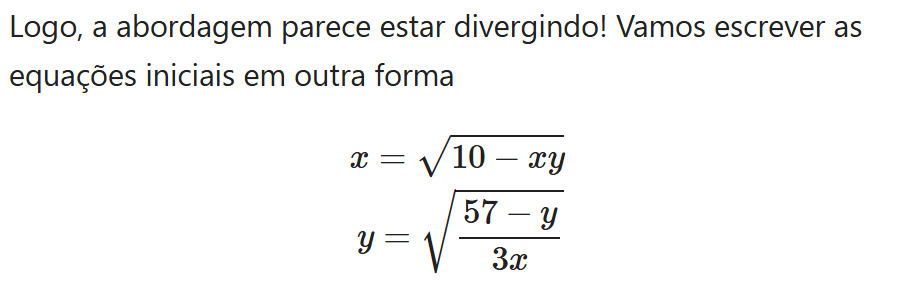

In [71]:

xi = 1.5
yi = 3.5
iteration = 5
for i in range(iteration):
    x_new = np.sqrt(10 - xi * yi)
    y_new = np.sqrt((57 - yi)/(3*x_new)) # x_new instead of xi
    erro_x = (x_new - xi)/x_new * 100
    erro_y = (y_new - yi)/y_new * 100
    print(f'x_new é {x_new} e o erro é {abs(erro_x)}')
    print(f'y_new é {y_new} e o erro é {abs(erro_y)}')
    print('----------')
    xi = x_new
    yi = y_new

x_new é 2.179449471770337 e o erro é 31.175279838831475
y_new é 2.860505988116444 e o erro é 22.355975290394102
----------
x_new é 1.9405338789116078 e o erro é 12.311848582243275
y_new é 3.0495506732218938 e o erro é 6.1990996498419
----------
x_new é 2.0204562858807944 e o erro é 3.955661279469126
y_new é 2.9834047467413445 e o erro é 2.217128820780951
----------
x_new é 1.9930281297863939 e o erro é 1.3762051666245265
y_new é 3.005704362568321 e o erro é 0.7419098200303954
----------
x_new é 2.0023852415506 e o erro é 0.4672982785750071
y_new é 2.998054303091251 e o erro é 0.2551674754250449
----------


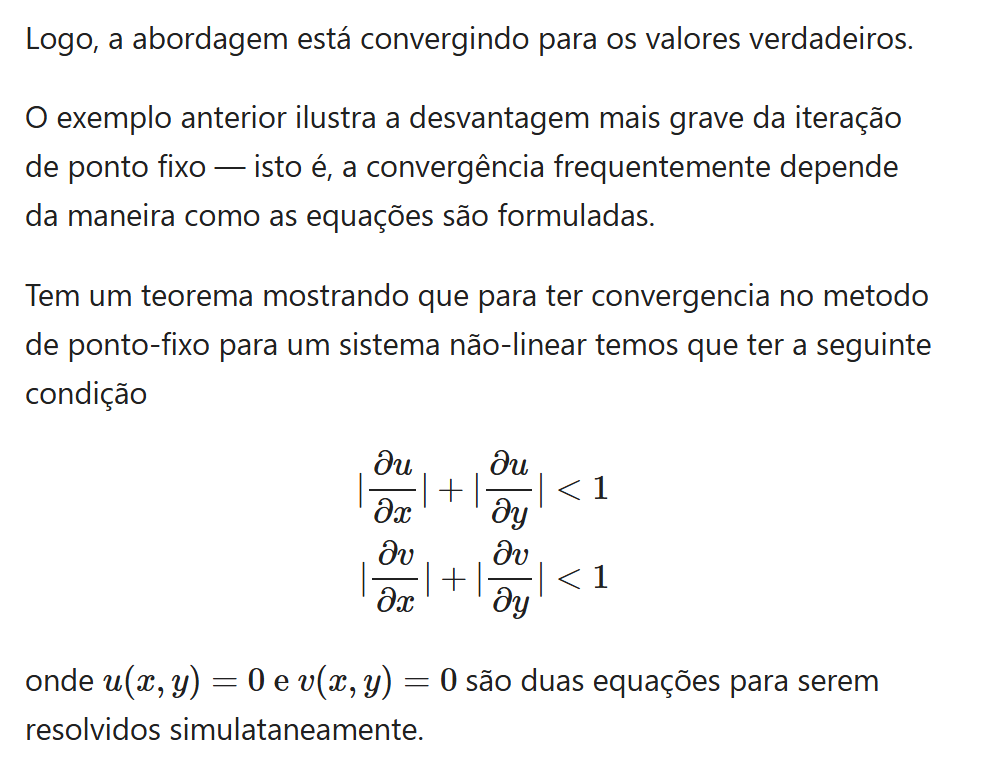

Newton-Raphson

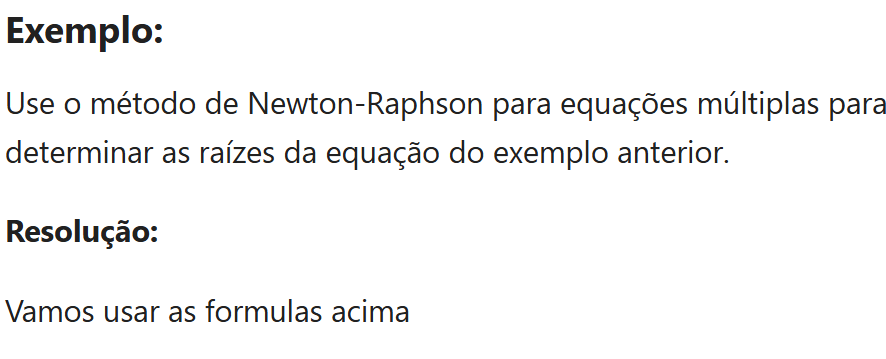

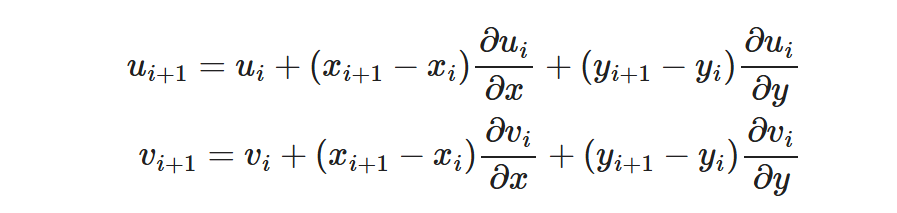

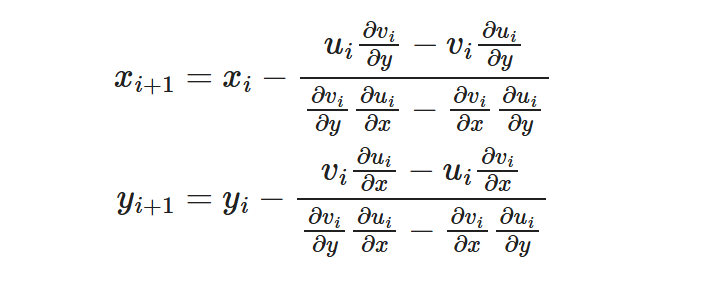

In [72]:
u = lambda x,y: x**2 + x*y - 10
v = lambda x, y: y + 3*x*y**2 - 57

dudx = lambda x, y: 2*x + y
dudy = lambda x, y: x
dvdx = lambda x, y: 3*y**2
dvdy = lambda x, y: 1 + 6*x*y


xi = 1.5
yi = 3.5

for i in range(5):
    jac = dudx(xi,yi)*dvdy(xi, yi) - dudy(xi, yi)*dvdx(xi, yi)
    x_new =  xi - (u(xi, yi)*dvdy(xi, yi) - v(xi, yi)*dudy(xi, yi))/jac
    y_new =  yi - (v(xi, yi)*dudx(xi, yi) - u(xi, yi)*dvdx(xi, yi))/jac
    erro_x = (x_new - xi)/x_new * 100
    erro_y = (y_new - yi)/y_new * 100
    print(f'x_new é {x_new} e o erro é {abs(erro_x)}')
    print(f'y_new é {y_new} e o erro é {abs(erro_y)}')
    print('----------')
    xi = x_new
    yi = y_new 

x_new é 2.0360288230584467 e o erro é 26.32717263075108
y_new é 2.843875100080064 e o erro é 23.071509009009013
----------
x_new é 1.9987006090558244 e o erro é 1.8676240870440306
y_new é 3.002288562924508 e o erro é 5.276423618991992
----------
x_new é 1.99999998387626 e o erro é 0.0649687415455565
y_new é 2.999999413388913 e o erro é 0.07630499944027892
----------
x_new é 1.99999999999998 e o erro é 8.061859957386812e-07
y_new é 3.000000000000075 e o erro é 1.9553705395598782e-05
----------
x_new é 2.0 e o erro é 9.992007221626409e-13
y_new é 3.0 e o erro é 2.5017025488220197e-12
----------


# EDO

## Métodos de Runge-Kutta

Metodo de Euler

In [73]:
def euler(func, xi, yi, h=1):
    return yi + func(xi, yi) * h

Método de Heun

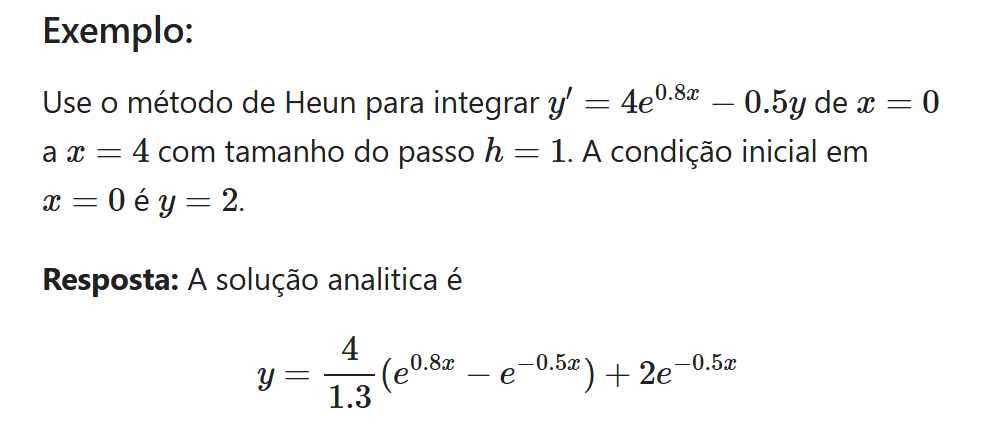

In [74]:
def heun(func, xi, yi, h, n=1):
    y1 = euler(func, xi, yi, h)
    for j in range(n):
        y_prime = func(xi+h, y1)
        y_mid = (y_prime + func(xi, yi))/2
        y_new = yi + y_mid * h
        y1 = y_new
    return y_new

In [75]:
func = lambda x, y: 4*np.exp(0.8 * x) - 0.5 * y

In [76]:
for n in range(1,10):
    print(heun(func, 0, 2, 1, n=n))

6.701081856984936
6.275811392738702
6.38212900880026
6.355549604784871
6.362194455788718
6.360533243037756
6.360948546225496
6.360844720428561
6.360870676877795



O Método do Ponto Médio (ou do Poligono Melhorado)

In [77]:
def mid_point(func, xi, yi, h):
    yi12 = yi + func(xi, yi)*(h/2)
    return yi + func(xi + (h/2), yi12) * h

In [78]:
mid_point(func, 0, 2, 1)

np.float64(6.217298790565081)


Comparar os três metodos

In [79]:
def compare(func, x0, y0, xf, h, methods= 'all'):
    num_steps = int((xf - x0)/h)
    xs = [x0 + n*h for n in range(num_steps+1)]

    if methods == 'all':
        ys = [[y0]*3]
        for i in range(1, num_steps+1):
            y_new = []
            y_new.append(euler(func, xs[i-1], ys[-1][-1], h))
            y_new.append(mid_point(func, xs[i-1], ys[-1][-1], h))
            y_new.append(heun(func, xs[i-1], ys[-1][-1], h, n))
            ys.append(y_new)
        
        ys_final = []
        methods = ['euler', 'mid_point', 'heun']
        for i in range(len(ys[0])):
            y_new = []
            for item in ys:
                y_new.append(item[i])
            y_new.append(methods[i])
            ys_final.append(y_new)


        return xs, ys_final

In [80]:
res = compare(func, 0, 2, 4, 1)

In [81]:
res[1]


[[2,
  np.float64(5.0),
  np.float64(12.082599052408769),
  np.float64(27.463255723931187),
  np.float64(61.46436206796073),
  'euler'],
 [2,
  np.float64(6.217298790565081),
  np.float64(15.030470935502347),
  np.float64(34.16709950426589),
  np.float64(76.4699813854895),
  'mid_point'],
 [2,
  np.float64(6.360870676877795),
  np.float64(15.302252052701455),
  np.float64(34.74331309078862),
  np.float64(77.73518044688431),
  'heun']]

O resultado analitico da EDO é o seguinte

In [82]:
y_analitic = lambda x: (4/1.3) * (np.exp(0.8*x) - np.exp(-0.5*x)) + 2 * np.exp(-0.5*x)


In [83]:
fig = go.Figure()

for y in res[1]:
    fig.add_scatter(x=res[0], y=y[:-1], name=y[-1] )
y_exact = list(map(y_analitic, res[0]))
fig.add_scatter(x=res[0], y=y_exact, name='analitic')
fig.show()

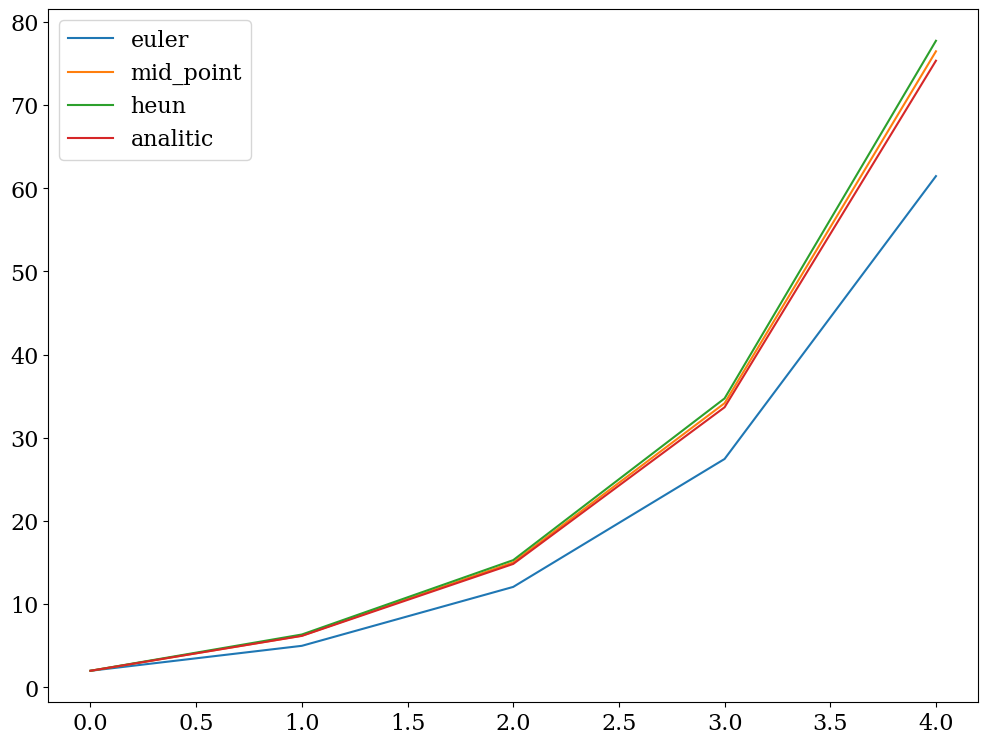

In [84]:
plt.figure(figsize=(12,9))

for y in res[1]:
    plt.plot(res[0], y[:-1], label=y[-1] )

y_exact = list(map(y_analitic, res[0]))
plt.plot(res[0], y_exact, label='analitic')
plt.legend()
plt.show()


Reduzindo o tamanho dos passos

In [85]:
res = compare(func, 0, 2, 4, 0.5)

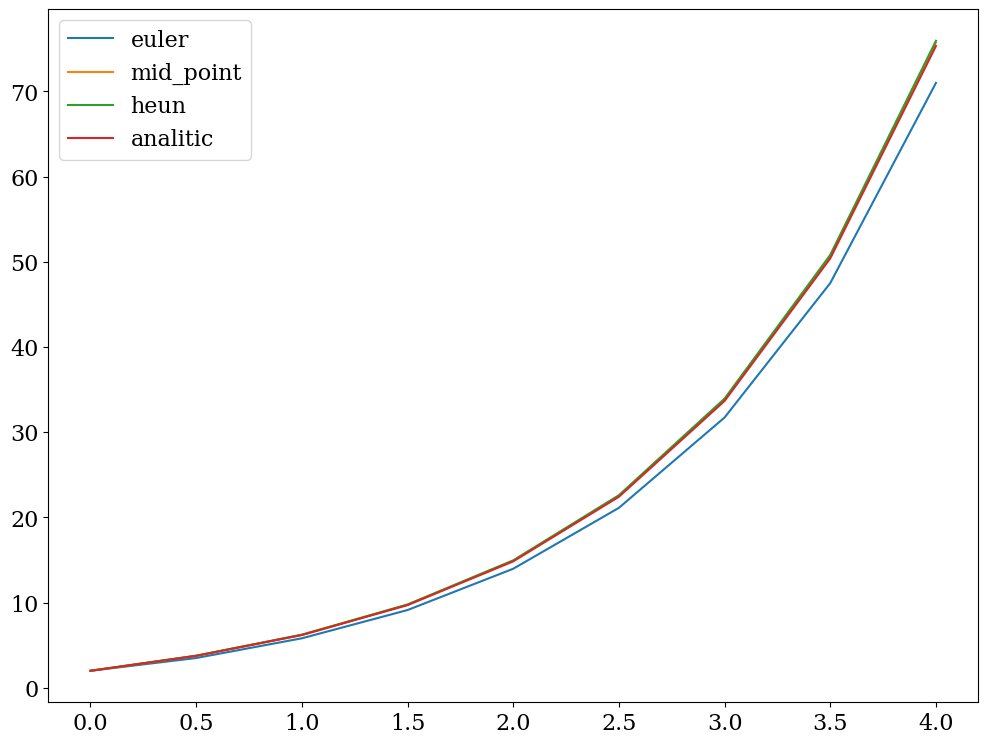

In [86]:
plt.figure(figsize=(12,9))

for y in res[1]:
    plt.plot(res[0], y[:-1], label=y[-1] )

y_exact = list(map(y_analitic, res[0]))
plt.plot(res[0], y_exact, label='analitic')
plt.legend()
plt.show()

Expansão de Taylor da ordem n

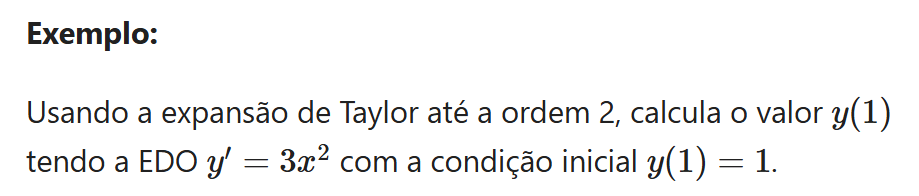

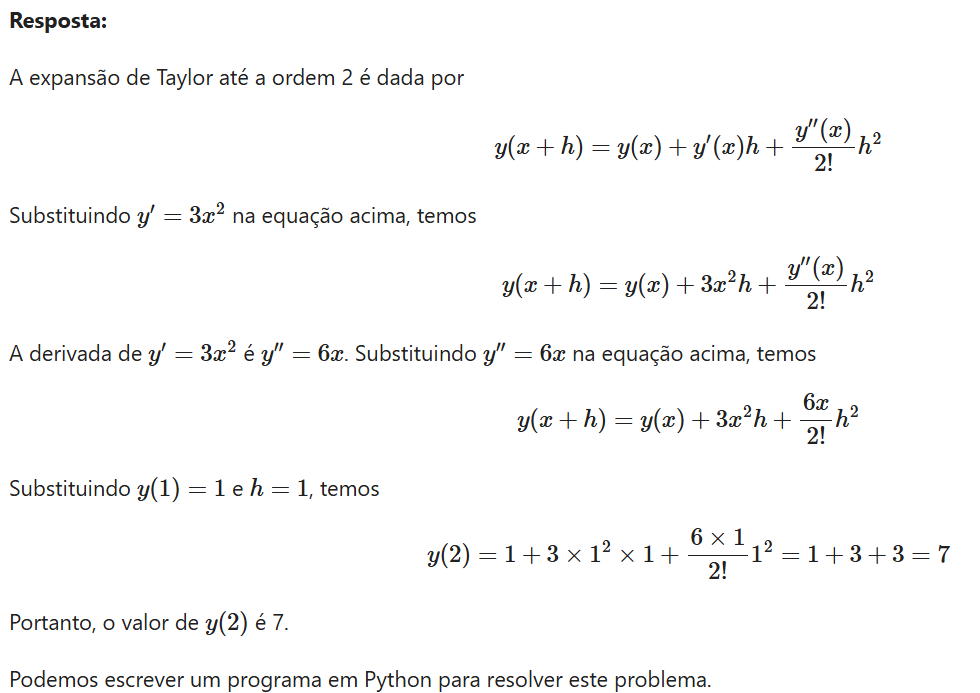

In [87]:
def taylor2(f, df, a, b, y0, N):
    h = (b-a)/N
    t = np.linspace(a, b, N+1)
    y = np.zeros(N+1)
    y[0] = y0
    for i in range(1, N+1):
        y[i] = y[i-1] + h*f(t[i-1], y[i-1]) + (h**2/2)*df(t[i-1], y[i-1])
    return t, y

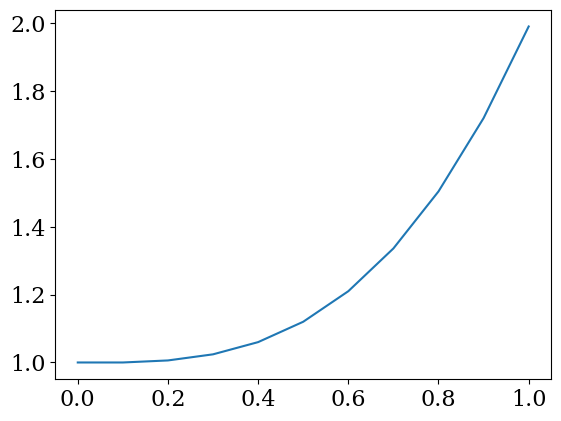

In [88]:
func = lambda x, y: 3*x **2
dfunc = lambda x, y: 6*x

t, y = taylor2(func, dfunc, 0, 1, 1, 10)

plt.plot(t, y)

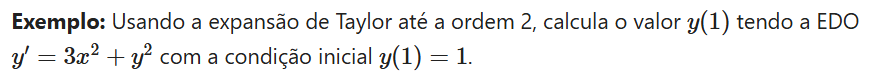

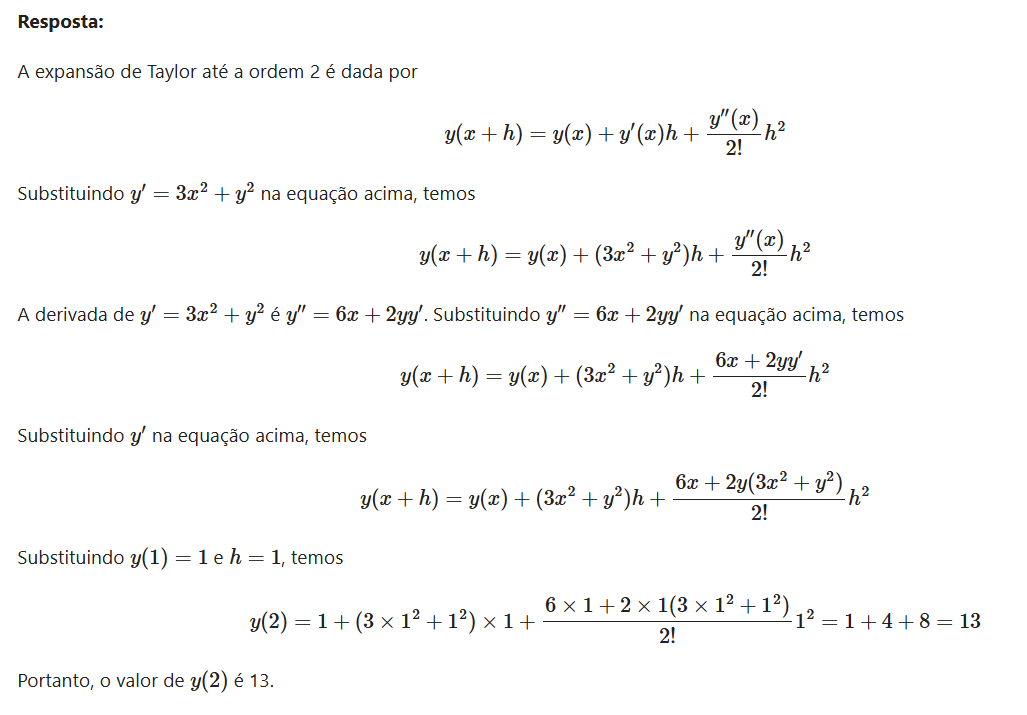

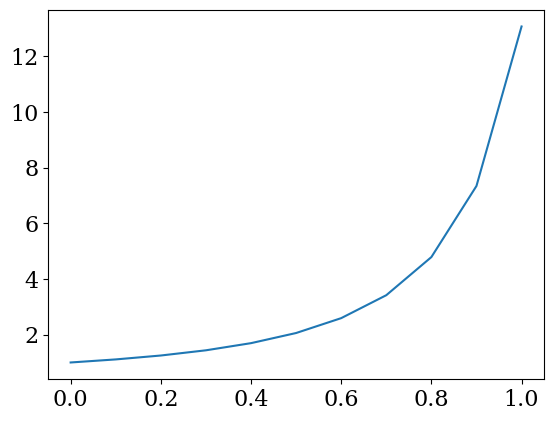

In [89]:
func = lambda x, y: 3*x **2 + y ** 2
dfunc = lambda x, y: 6*x + 2*y

t, y = taylor2(func, dfunc, 0, 1, 1, 10)

plt.plot(t, y)

## Métodos de Runge-Kutta de Quarta Ordem

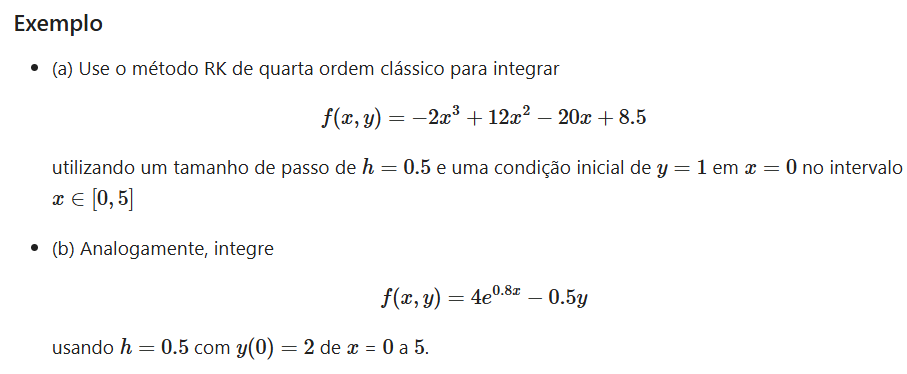

In [90]:
def _RK4(func, xi, yi, h):
    k1 = func(xi, yi)
    k2 = func(xi+0.5*h, yi+(k1*h)/2)
    k3 = func(xi+0.5*h, yi+(k2*h)/2)
    k4 = func(xi+h, yi+k3*h)

    return yi + ((k1 + 2*k2 + 2*k3 + k4)*h)/6

In [91]:
def RK4(func, xi, yi, xf, h=0.1):
    x = [xi]
    y = [yi]
    while x[-1] < xf:
        yi = _RK4(func, x[-1], y[-1], h)
        xi += h
        x.append(xi)
        y.append(yi)
    
    return x, y

In [92]:
f = lambda x, y: -2*x**3 + 12*x**2 - 20*x + 8.5

In [93]:
x1, y1 = RK4(f, 0, 1, 5, 0.5)
x2, y2 = RK4(f, 0, 1, 5, 0.01)

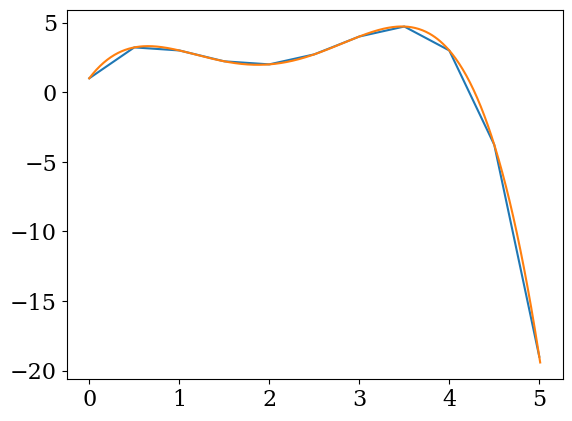

In [94]:
plt.plot(x1,y1)
plt.plot(x2,y2)
plt.show()

In [95]:
x_eval = np.linspace(0, 5, 100)
res = solve_ivp(f,(0,5),[1], t_eval=x_eval)

In [96]:
res.success


True

In [97]:
res


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.051e-02 ...  4.949e+00  5.000e+00]
        y: [[ 1.000e+00  1.404e+00 ... -1.697e+01 -1.900e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 20
     njev: 0
      nlu: 0

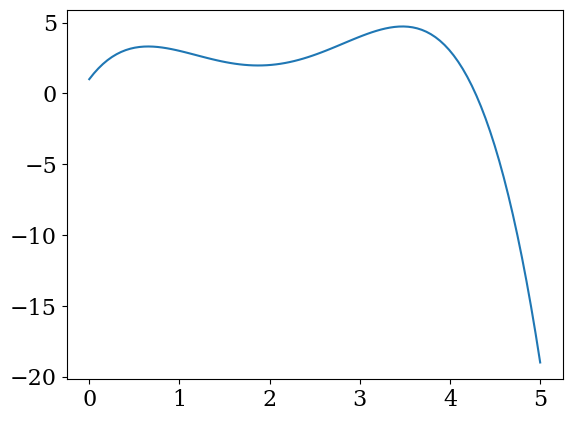

In [98]:
plt.plot(x_eval, res.y[0])



## Metodos de Runge-Kutta de ordem superiores

O Método de Euler

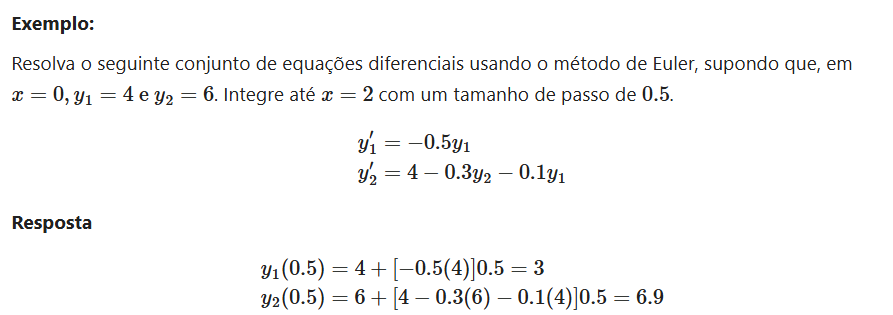

In [99]:
def _Euler(funcs, xi, yis, h):
    n = len(funcs)
    y = []
    for i in range(n):
        y.append(yis[i] + funcs[i](xi, *yis)*h)
    return y
        

In [100]:
def EulerSys(funcs, interval, yis, h):
    assert len(funcs) == len(yis), "yis and funcs must have the same size"
    xi, xf = interval
    X = [xi]
    Y = [yis]
    while xi < xf:
        y = _Euler(funcs, xi, Y[-1], h)
        Y.append(y)
        X.append(xi)
        xi += h
    return X, Y

In [101]:
f1 = lambda x, y1, y2: -0.5 * y1
f2 = lambda x, y1, y2: 4 - 0.3*y2 - 0.1 * y1
x0 = 0
xf = 2
interval = (x0 ,xf)
h = 0.1
yis = [4, 6]

In [102]:
X, Y = EulerSys((f1, f2), interval, yis, h)


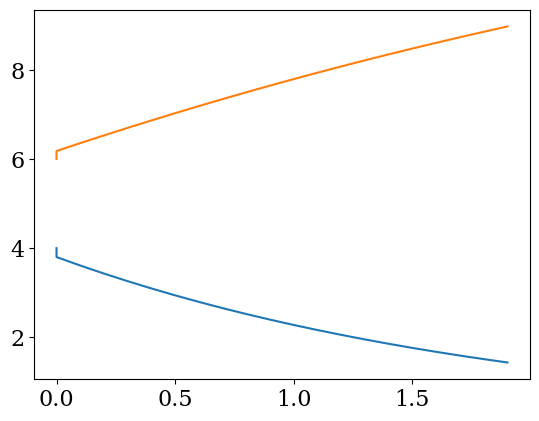

In [103]:
plt.plot(X, Y)
plt.show()

usando Scipy

In [104]:
def Eq(x, arg):
    y1 = f1(x, *arg)
    y2 = f2(x, *arg)
    return y1, y2

In [105]:
t = np.linspace(x0, xf, 100)
res = solve_ivp(Eq, (x0,xf), [4, 6], t_eval=t)

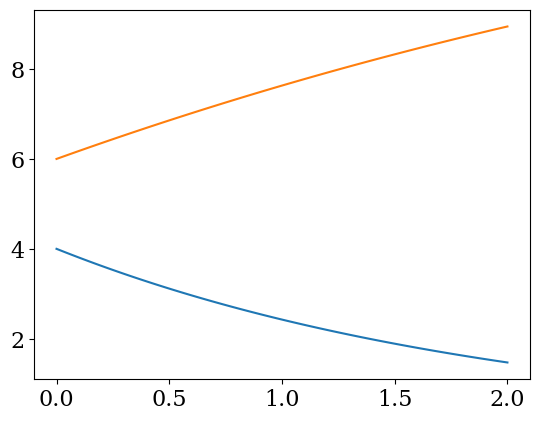

In [106]:
plt.plot(res.t, res.y[0])
plt.plot(res.t, res.y[1])
plt.show()

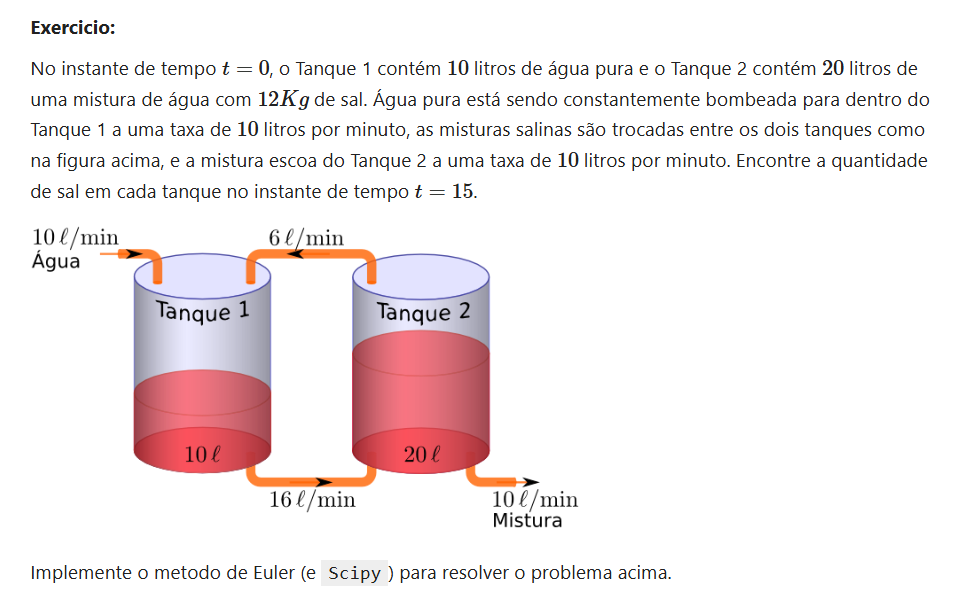

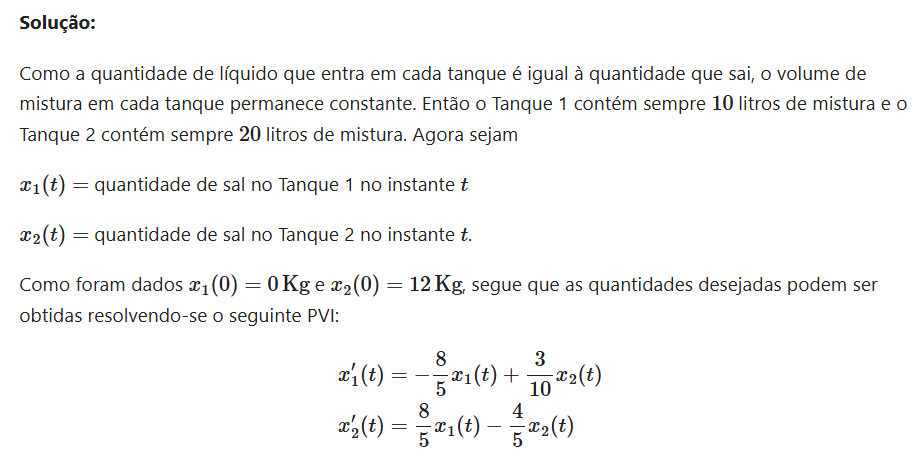

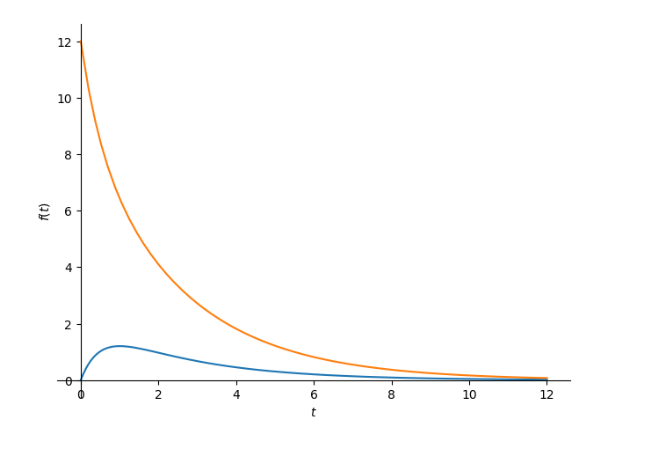

Métodos de Runge-Kutta

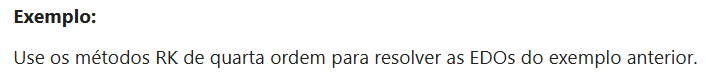

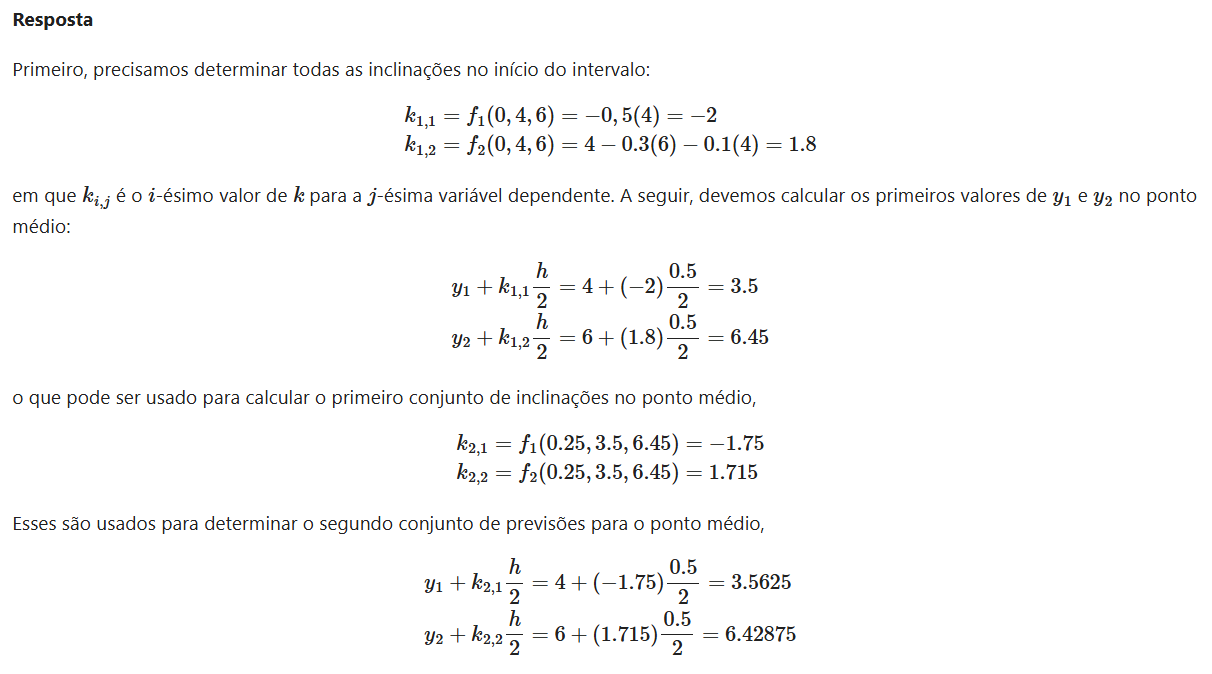

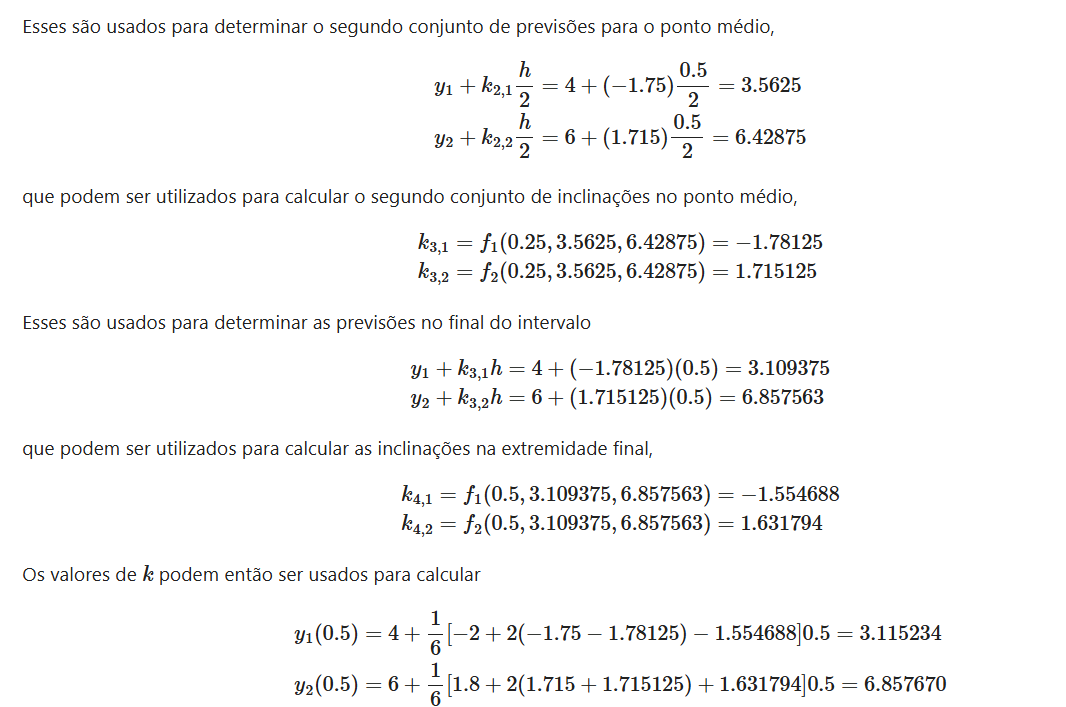

## Algoritmos Computacionais para a Resolução de Sistemas de EDOs

 O código computacional para resolver uma única EDO pelo método de Euler pode ser facilmente estendido para sistemas de equações. As modificações incluem:

Entrar o número de equações, n.
Entrar os valores iniciais de cada uma das n variáveis dependentes.
Modificar o algoritmo de modo que ele calcule inclinações para cada uma das variáveis dependentes.
Incluir equações adicionais para calcular os valores da derivada para cada uma das EDOs.
Incluir laços para calcular um novo valor para cada variável dependente.

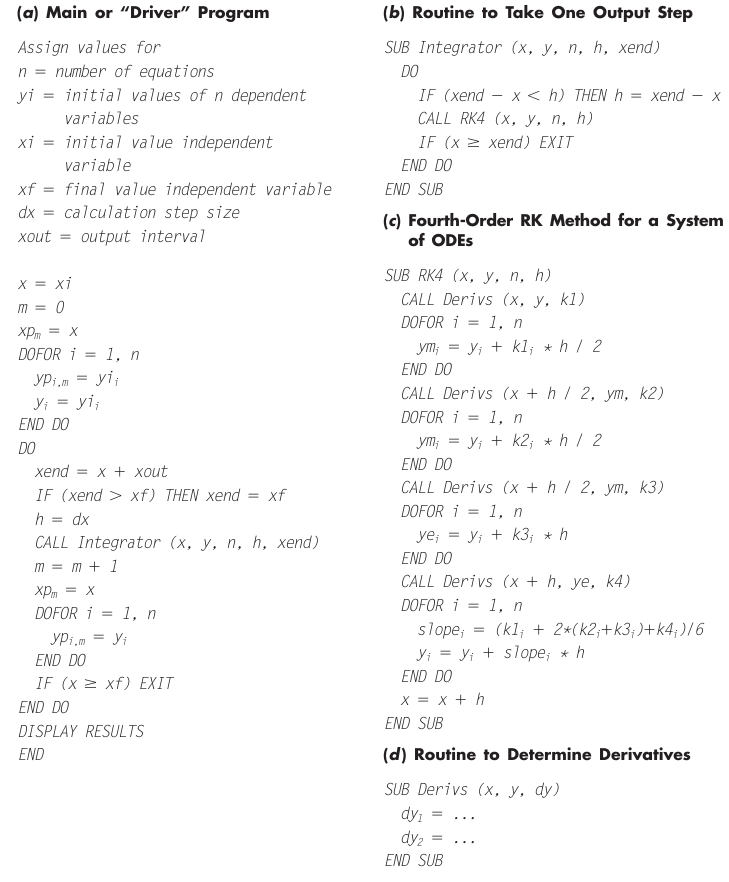

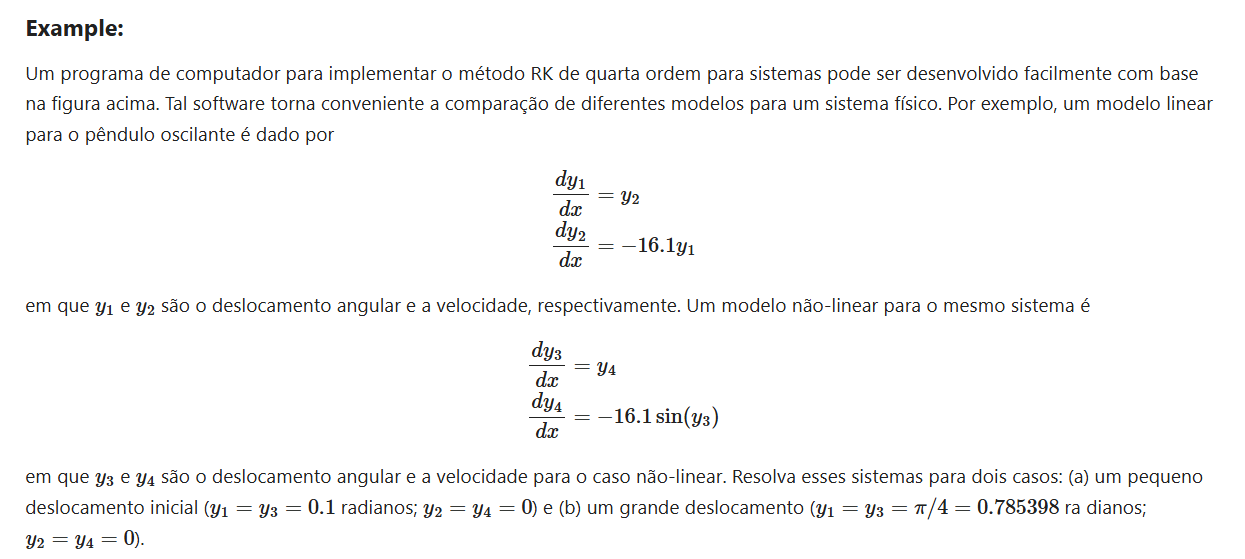

In [107]:
f1 = lambda x,y1, y2, y3, y4: y2
f2 = lambda x, y1, y2, y3, y4: -16.1 * y1 
f3 = lambda x, y1, y2, y3, y4: y4
f4 = lambda x, y1, y2, y3, y4: -16.1 * np.sin(y3)

funcs = [f1, f2, f3, f4]

x0 = 0
xf = 4

y0s = [0.1, 0, 0.1, 0]

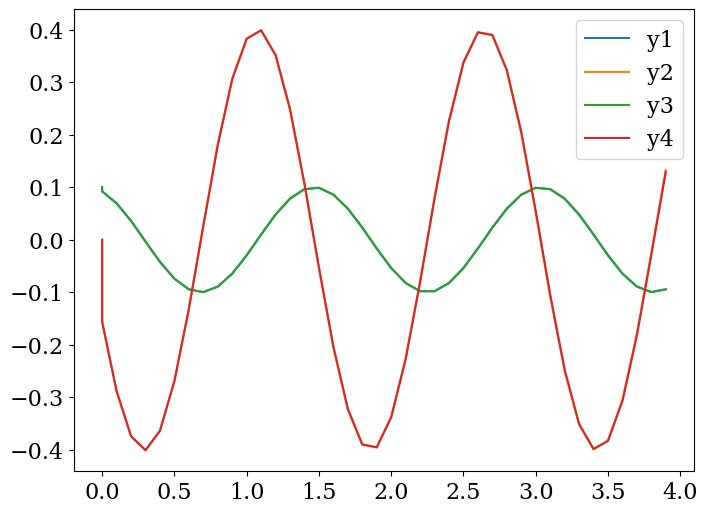

In [108]:
def RK4sys(funcs, interval, y0s, h=0.1):
    assert len(funcs) == len(y0s), "y0s and funcs must have the same size"
    xi, xf = interval
    X = [xi]
    Y = [y0s]
    while xi < xf:
        k1 = [f(xi, *Y[-1]) for f in funcs]
        k2 = [f(xi + 0.5*h, *(Y[-1][i] + 0.5*k1[i]*h for i in range(len(Y[-1])))) for f in funcs]
        k3 = [f(xi + 0.5*h, *(Y[-1][i] + 0.5*k2[i]*h for i in range(len(Y[-1])))) for f in funcs]
        k4 = [f(xi + h, *(Y[-1][i] + k3[i]*h for i in range(len(Y[-1])))) for f in funcs]

        y_new = [Y[-1][i] + (k1[i] + 2*k2[i] + 2*k3[i] + k4[i])*h/6 for i in range(len(Y[-1]))]
        
        Y.append(y_new)
        X.append(xi)
        xi += h
    return X, Y
X, Y = RK4sys(funcs, (x0, xf), y0s)
plt.figure(figsize=(8,6))
plt.plot(X, Y)
plt.legend(('y1', 'y2', 'y3', 'y4'))
plt.show()

 usando scipy

In [109]:
f1 = lambda x,y1, y2, y3, y4: y2
f2 = lambda x, y1, y2, y3, y4: -16.1 * y1 
f3 = lambda x, y1, y2, y3, y4: y4
f4 = lambda x, y1, y2, y3, y4: -16.1 * np.sin(y3)

def Eq(t, args):
    y1 = f1(t, *args)
    y2 = f2(t, *args)
    y3 = f3(t, *args)
    y4 = f4(t, *args)
    return y1, y2, y3, y4

x0 = 0
xf = 4
interval = (x0, xf)
y0s = [0.1, 0, 0.1, 0]
t_eval = np.linspace(0, 4, 100)

res = solve_ivp(Eq, interval, y0s, t_eval=t_eval)

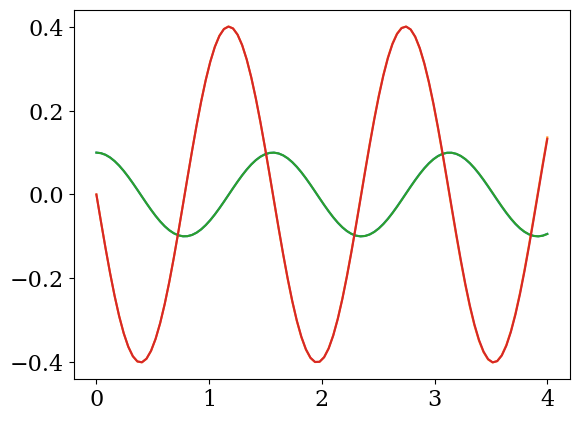

In [110]:
plt.plot(t_eval, res.y.T)

In [111]:
fig = go.Figure()
fig.add_scatter(x=t_eval, y=res.y[0])
fig.add_scatter(x=t_eval, y=res.y[1])
fig.add_scatter(x=t_eval, y=res.y[2])
fig.add_scatter(x=t_eval, y=res.y[3])

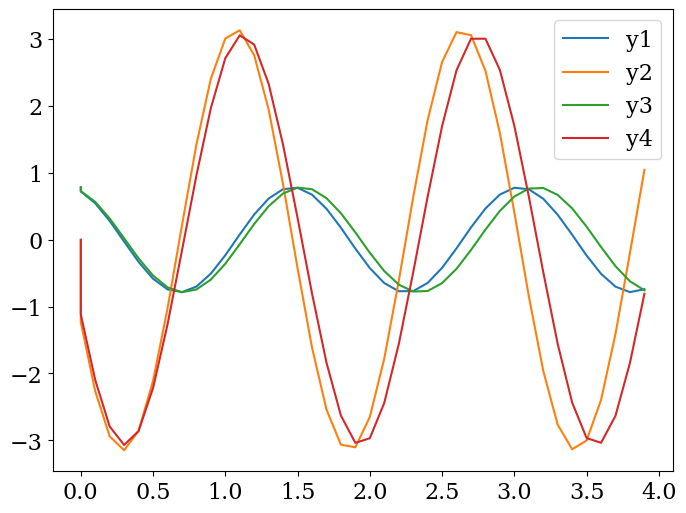

In [112]:
y0s = [0.785398, 0, 0.785398, 0]

X, Y = RK4sys(funcs, (x0, xf), y0s)

plt.figure(figsize=(8,6))
plt.plot(X, Y)
plt.legend(('y1', 'y2', 'y3', 'y4'))
plt.show()

In [113]:
y0s = [0.785398, 0, 0.785398, 0]

res = solve_ivp(Eq, interval, y0s, t_eval=t_eval)

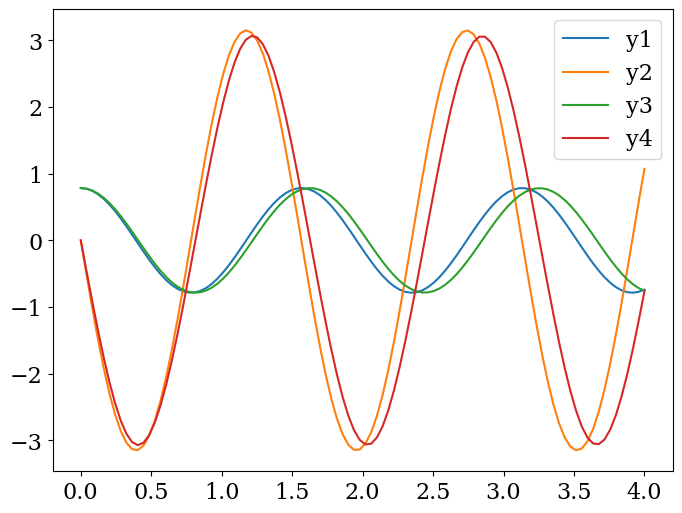

In [114]:
plt.figure(figsize=(8,6))
plt.plot(t_eval, res.y.T)
plt.legend(('y1', 'y2', 'y3', 'y4'))
plt.show()

## EDO de segunda ordem

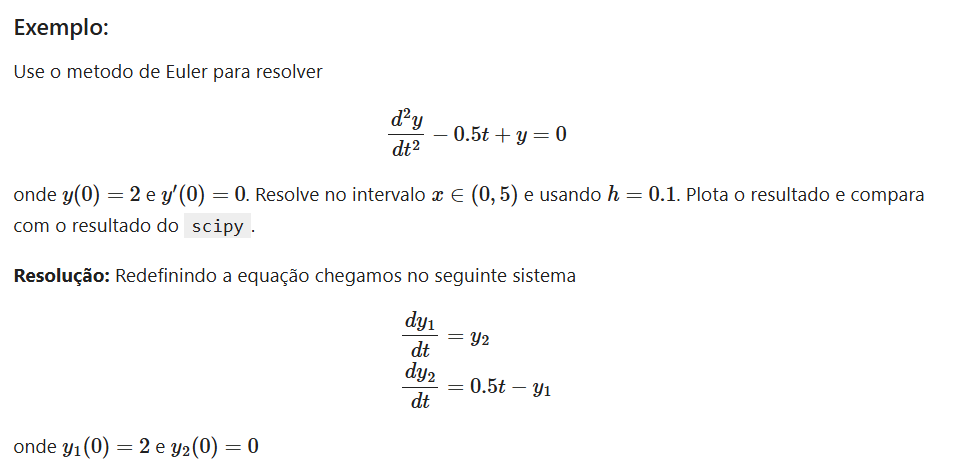

In [115]:
f1 = lambda t, y1, y2: y2
f2 = lambda t, y1, y2: 0.5*t - y1
x0 = 0.
xf = 5.
interval = (x0 ,xf)
h = 0.01
yis = [2., 0.]

In [116]:
X, Y = EulerSys((f1, f2), interval, yis, h)

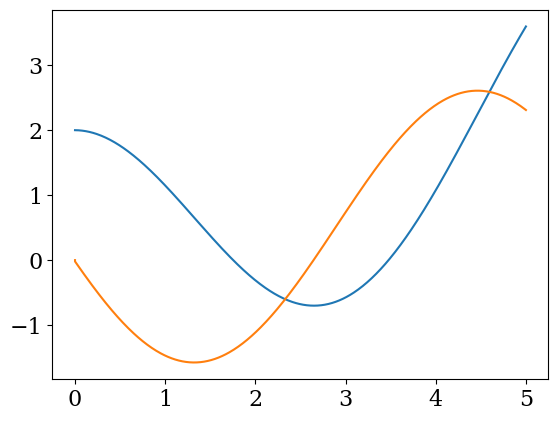

<Figure size 800x600 with 0 Axes>

In [117]:
plt.plot(X, Y)
plt.figure(figsize=(8,6))
plt.show()

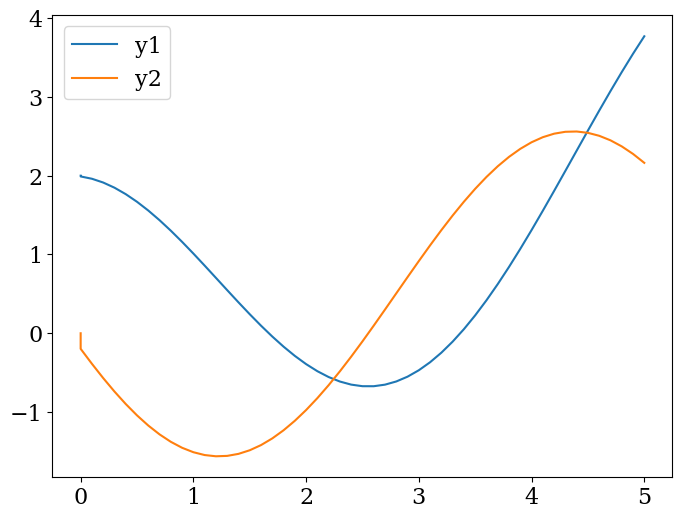

In [118]:
X, Y = RK4sys((f1, f2), (x0, xf), yis)
plt.figure(figsize=(8,6))
plt.plot(X, Y)
plt.legend(('y1', 'y2'))
plt.show()

In [119]:
def Eq(x, arg):
    y1 = f1(x, *arg)
    y2 = f2(x, *arg)
    return y1, y2

In [120]:
t_eval = np.linspace(x0, xf, 100)
res = solve_ivp(Eq, interval, yis, t_eval=t_eval)

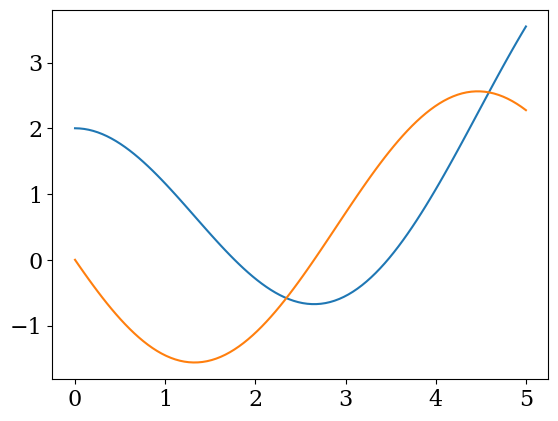

In [121]:
plt.plot(t_eval, res.y.T)
plt.show()

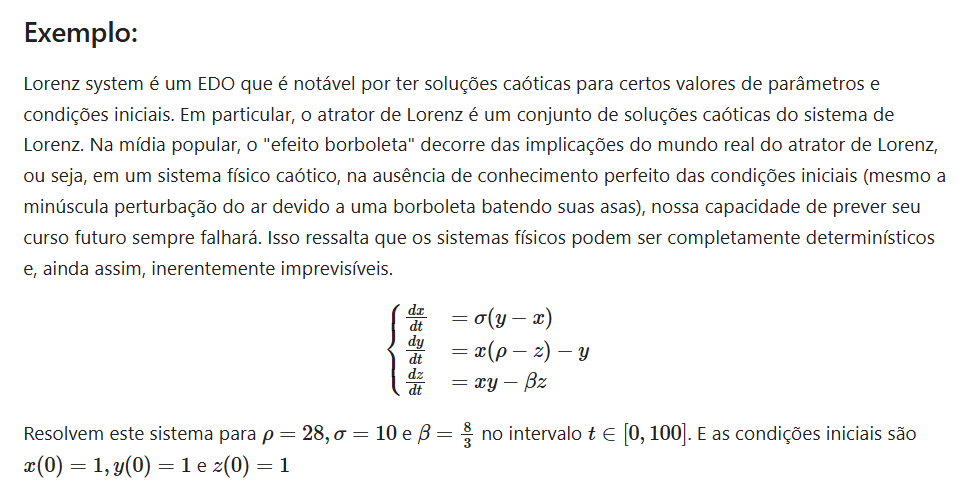

## Métodos de Runge-Kutta Adaptativos

Método RK Adaptativo ou de Divisão do Passo na Metade

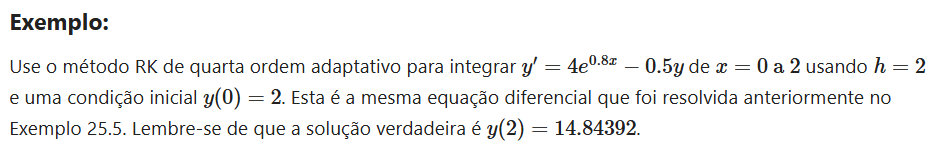

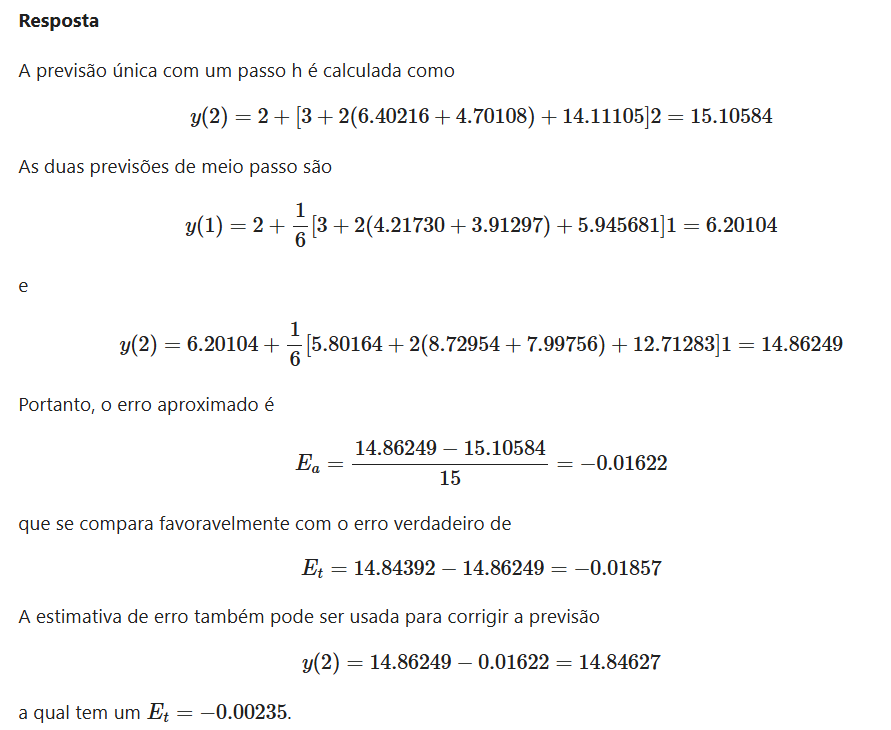

Runge-Kutta Fehlberg

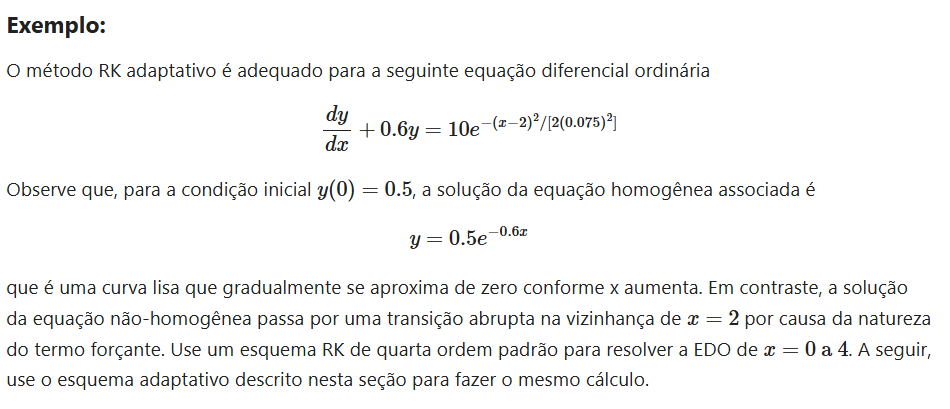

scipy

In [122]:
x0 = 0
y0 = 0.5
func = lambda x, y: 10*np.exp(-(x-2)**2/(2*0.075**2)) - 0.6*y


In [123]:
res = solve_ivp(func, (0,4), [0.5], t_eval=np.linspace(0,4, 200), method='RK45')


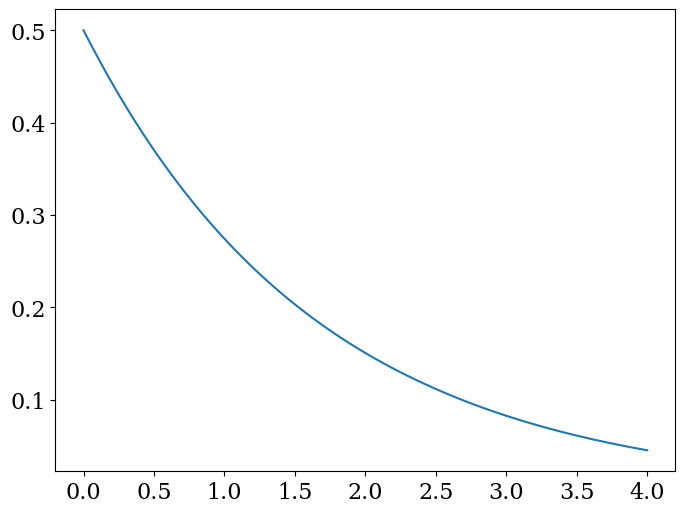

In [124]:
plt.figure(figsize=(8,6))
plt.plot(res.t, res.y[0])
plt.show()

Agora vamos um metodo adaptativo

In [125]:
res = solve_ivp(func, (0,4), [0.5], t_eval=np.linspace(0,4, 200), method='LSODA')


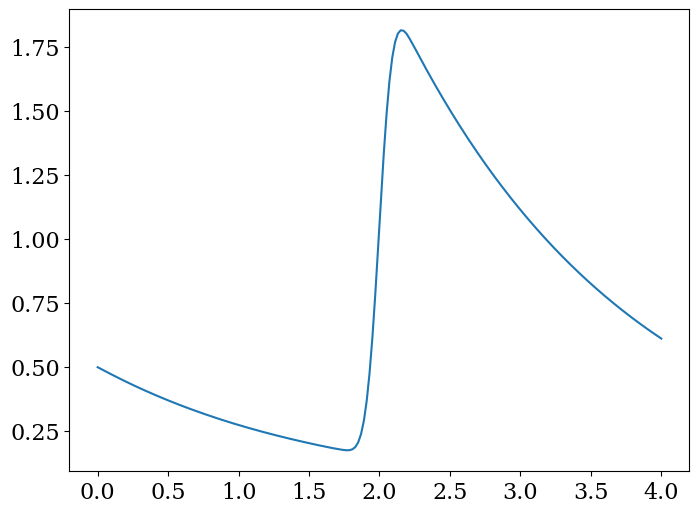

In [126]:
plt.figure(figsize=(8,6))
plt.plot(res.t, res.y[0])
plt.show()

## Rigidez e Métodos de Passo Múltiplo

Rigidez

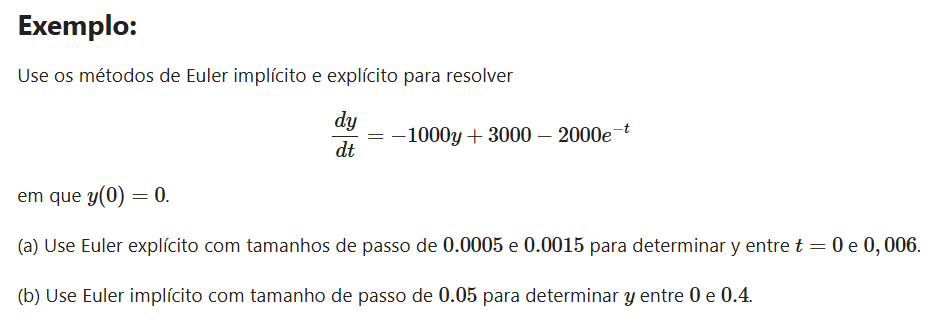

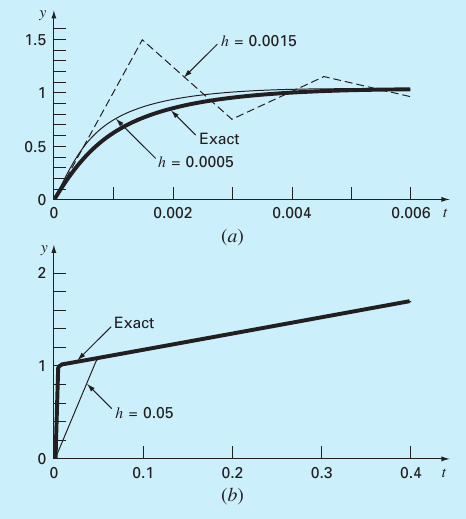


O Método de Heun de Início Não-automático

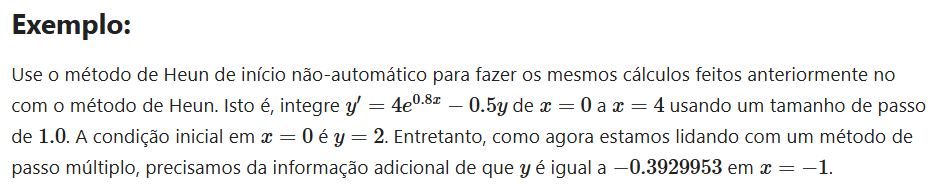

In [127]:
def heun_NA(func, xi, yis, h, n=1):
    y1 = yis[1] + func(xi, yis[0])*(2*h)
    for j in range(n):
        y_prime = func(xi+h, y1)
        y_mid = (y_prime + func(xi, yis[0]))/2
        y_new = yis[0] + y_mid * h
        y1 = y_new
    return y_new

In [128]:
f = lambda x, y: 4*np.exp(0.8*x) - 0.5*y
x0 = 0
y0 = (-0.3929953, 2)
h = 1.
xf = 4

In [129]:
for i in range(5):
    print(x0, y0)
    y = heun_NA(f, x0, y0, h, n=5)
    x0 += h
    y0 = (y0[1], y)

0 (-0.3929953, 2)
1.0 (2, np.float64(4.919728533132468))
2.0 (np.float64(4.919728533132468), np.float64(12.677867424584534))
3.0 (np.float64(12.677867424584534), np.float64(28.495344814306712))
4.0 (np.float64(28.495344814306712), np.float64(64.45726988788691))


E o metodo de Euler dá

In [130]:
def euler(func, xi, yi, h=1):
    return yi + func(xi, yi) * h

In [131]:
x0 = 0
y0 = 2
h = 1.
xf = 4
for i in range(5):
    print(x0, y0)
    y0 = euler(f, x0, y0, h)
    x0 += h

0 2
1.0 5.0
2.0 11.402163713969871
3.0 25.513211554565395
4.0 56.84931129984912


Vamos perguntar para o scipy

In [132]:
res = solve_ivp(f, (0,4), [2])
res.y

array([[ 2.        ,  2.28411606,  6.27881264, 24.06083504, 75.34536894]])

## Problemas de Contorno e de Autovalores

## Métodos Gerais para Problemas de Contorno

O Método Shooting

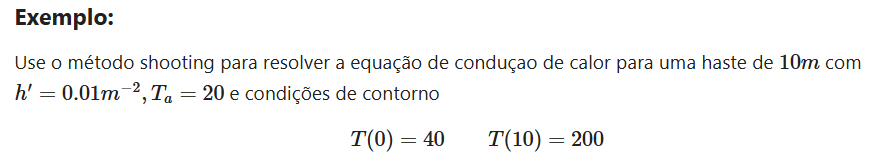

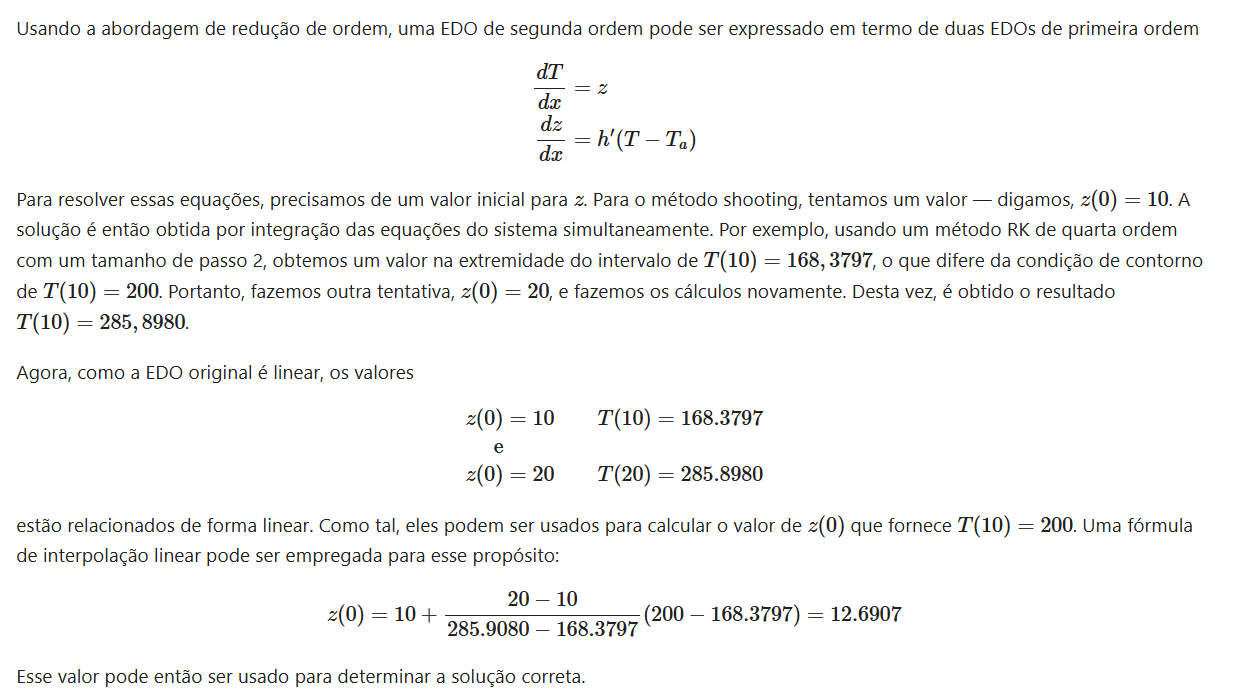

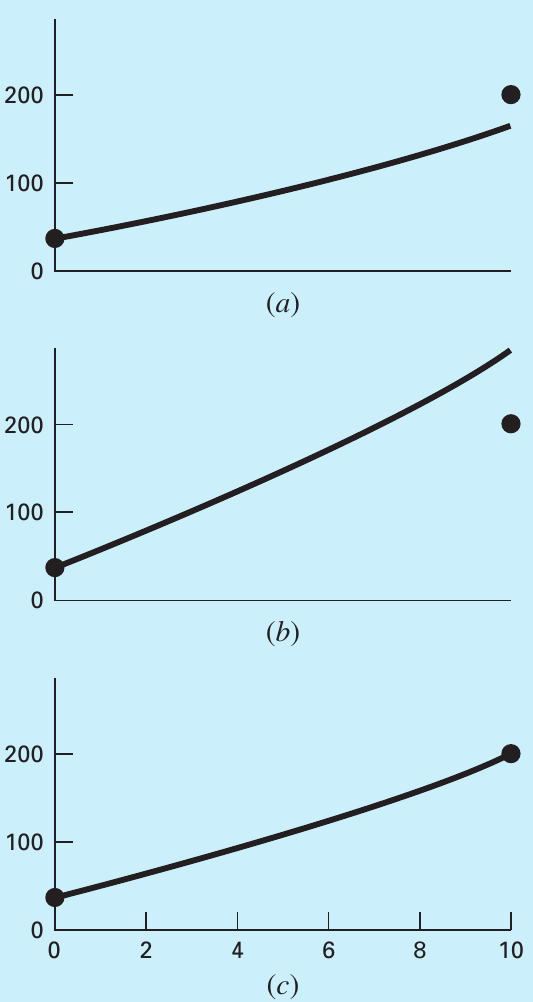

O método shooting para os Problemas Não-lineares de Dois Pontos

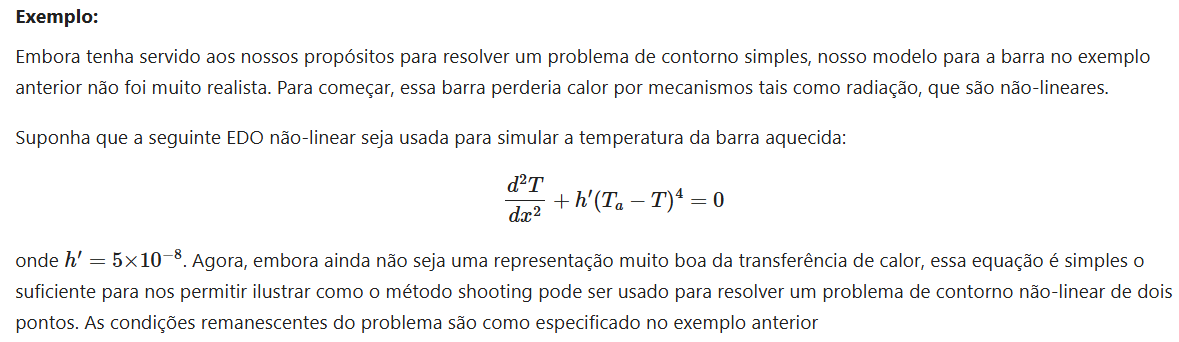

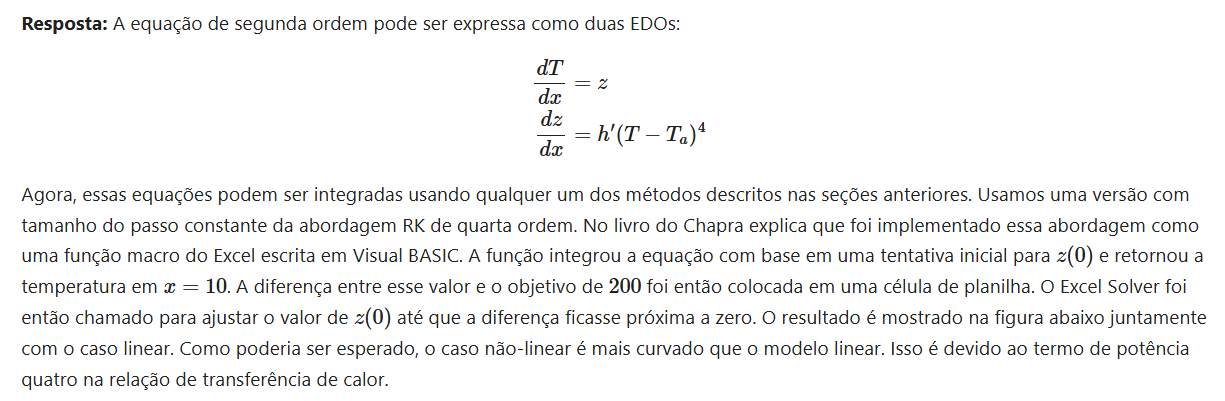

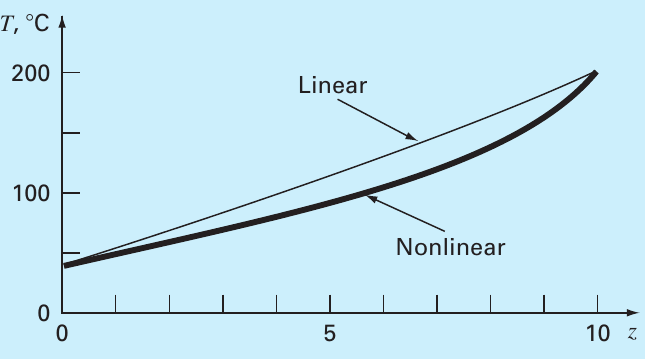

Métodos de Diferenças Finitas

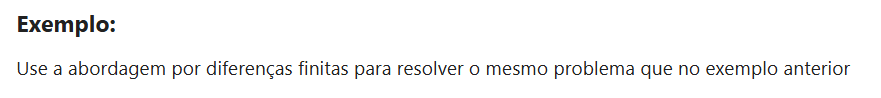

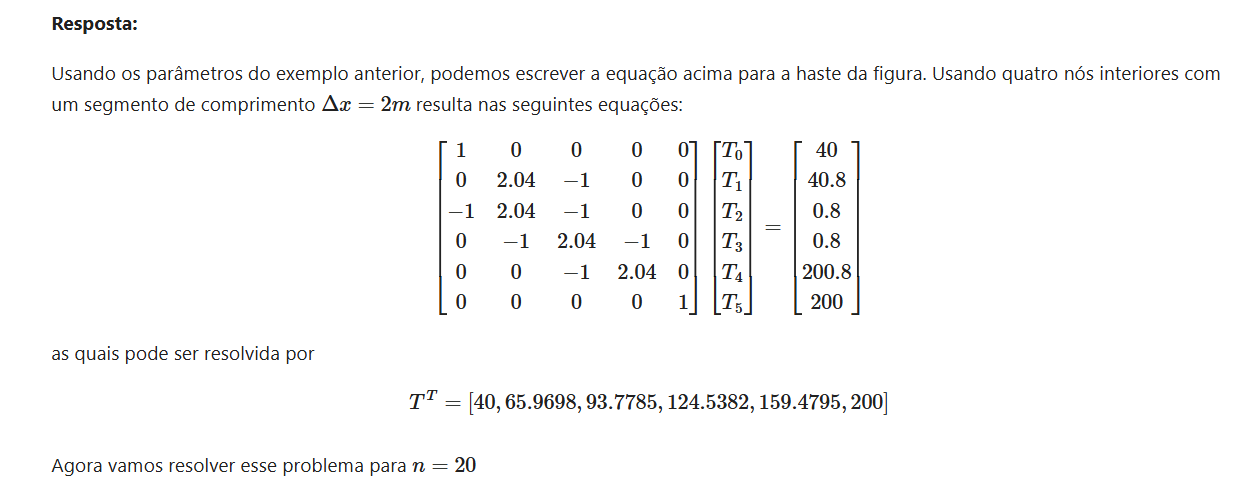

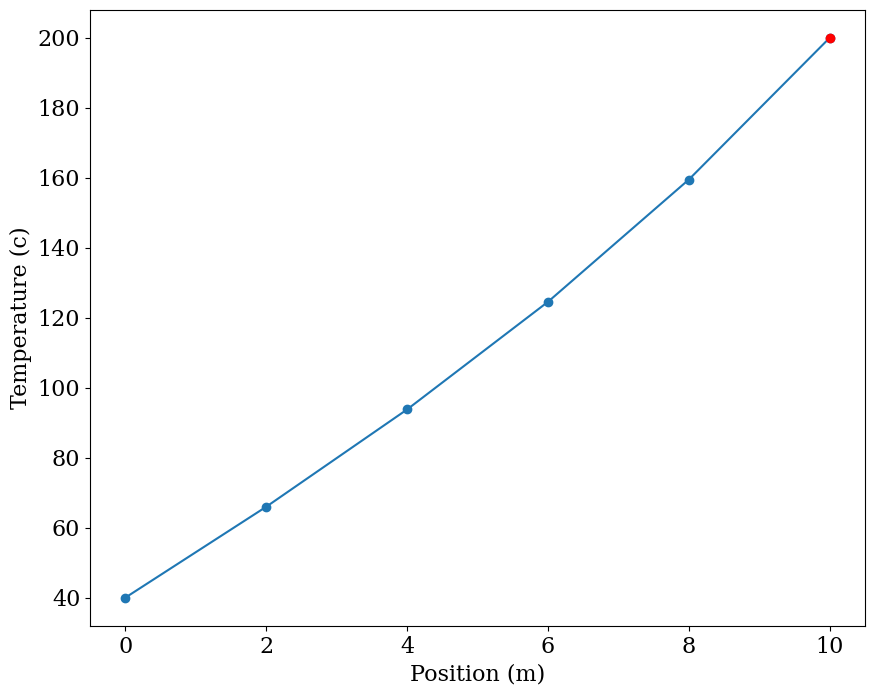

In [133]:
n = 5
dx = (10-0) / n

h = 0.01
ta = 20

# Get A
A = np.zeros((n+1, n+1))
A[0, 0] = 1
A[n, n] = 1
for i in range(1, n):
    A[i, i-1] = -1
    A[i, i] = 2 + h*dx**2
    A[i, i+1] = -1

#print(A)

# Get b
b = np.zeros(n+1)
b[0] = 40
b[1:-1] = ta*h*dx**2
b[-1] = 200
#print(b)

# solve the linear equations
y = np.linalg.solve(A, b)

x = np.linspace(0, 10, n+1)

plt.figure(figsize=(10,8))
plt.plot(x, y, marker='o')
plt.plot(10, 200, 'ro')
plt.xlabel('Position (m)')
plt.ylabel('Temperature (c)')
plt.show()

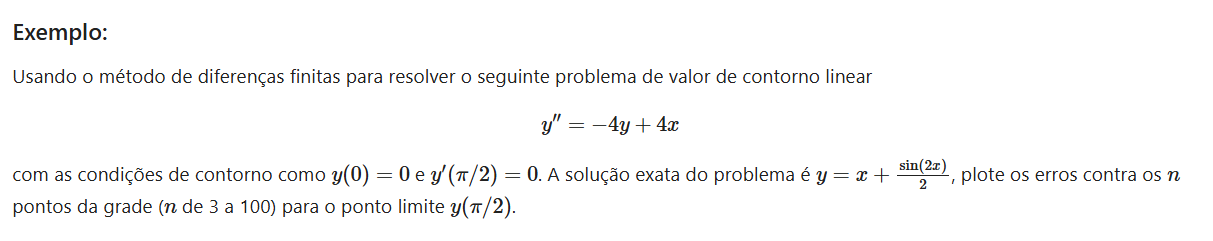

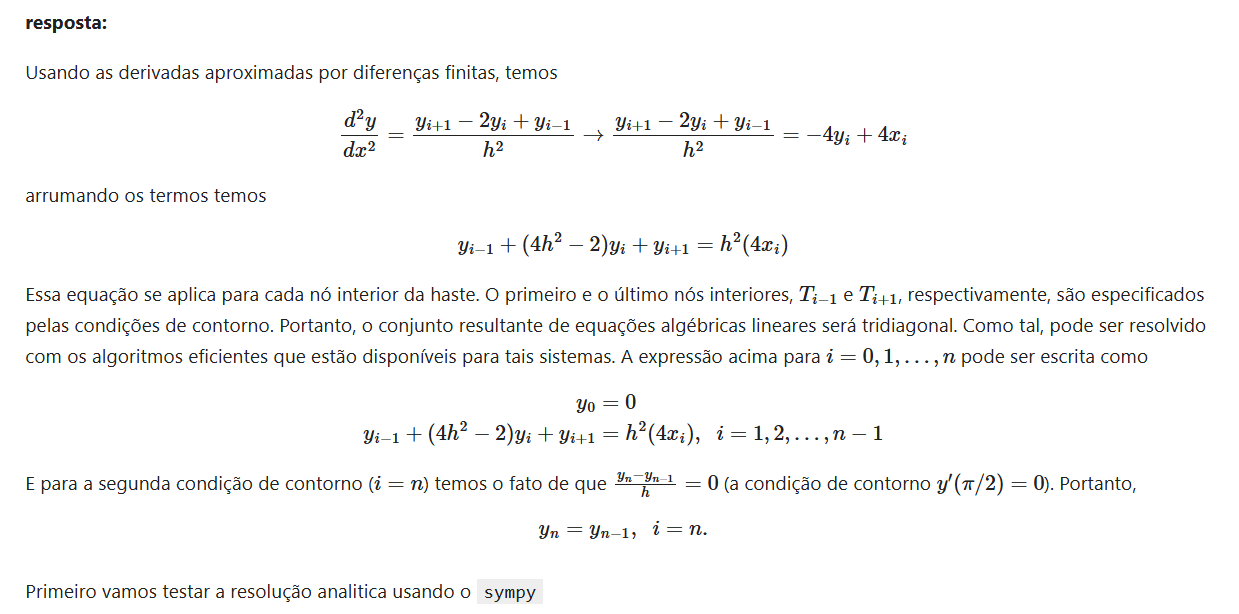

In [134]:
x= sp.symbols('x')
y = sp.Function('y')

eq = sp.Eq(y(x).diff(x,2), -4*y(x)+4*x)
sp.dsolve(eq, y(x), ics={y(x).subs(x,0):0, y(x).diff(x).subs(x,sp.pi/2):0})

Eq(y(x), x + sin(2*x)/2)

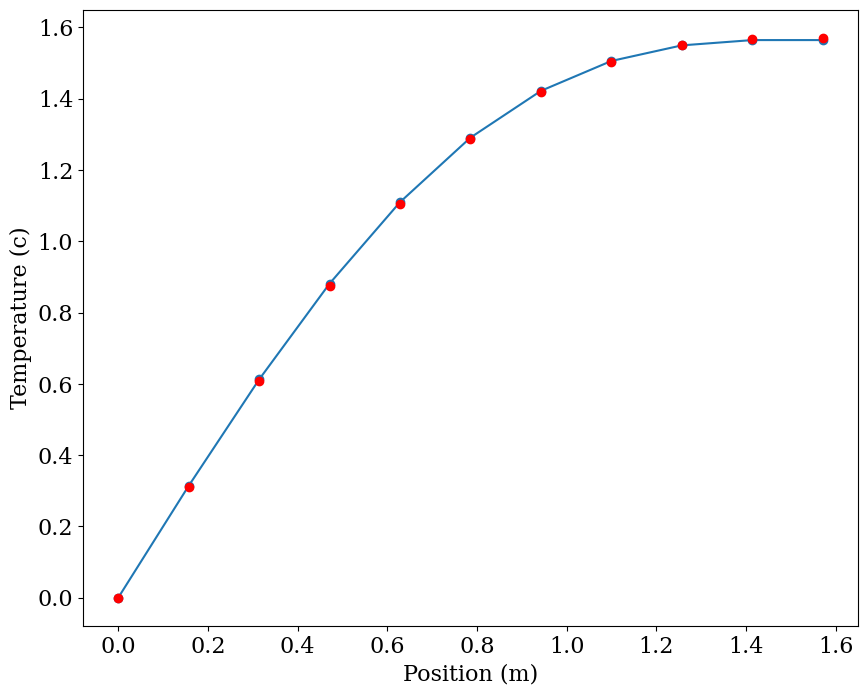

In [135]:
n = 10
dx = (np.pi/2-0) / n

# Get A
A = np.zeros((n+1, n+1))
A[0, 0] = 1
A[n, n] = 1
A[n, n-1] = -1
for i in range(1, n):
    A[i, i-1] = 1
    A[i, i] = 4* dx**2 - 2
    A[i, i+1] = 1

#print(A)

# Get b
b = np.zeros(n+1)
b[0] = 0
for i in range(1, n):
    b[i] = 4*dx**2 *(i*dx)
b[-1] = 0

#print(b)

# solve the linear equations
y = np.linalg.solve(A, b)

x = np.linspace(0, np.pi/2, n+1)
f = lambda x: x + np.sin(2*x)/2

plt.figure(figsize=(10,8))
plt.plot(x, y, marker='o')
plt.plot(x, f(x), 'ro')
plt.xlabel('Position (m)')
plt.ylabel('Temperature (c)')
plt.show()

## Um Estudo de Caso: Modelos Predador-Presa e Caos

In [136]:
p = [1, -2, 1]

np.roots(p)

array([1., 1.])

In [137]:
x = sp.symbols('x')

In [138]:
pol = (2 - 0.5625*x**2)**3 - 2*(2 - 0.5625*x**2)

In [139]:
sp.solve(pol)

[-2.46367875336343,
 -1.88561808316413,
 -1.02048915297357,
 1.02048915297357,
 1.88561808316413,
 2.46367875336343]

In [140]:
a = np.array([[0.422,  0.281,  0.141],[ 0.281,  0.562,  0.281], [0.141 , 0.281,  0.422]] )
np.linalg.inv(a)*0.5625

array([[ 1.99823011, -0.99734043, -0.00354925],
       [-0.99734043,  1.99823011, -0.99734043],
       [-0.00354925, -0.99734043,  1.99823011]])

# EDP

## Diferenças Finitas: Equações Elípticas

A Equação de Diferença de Laplace

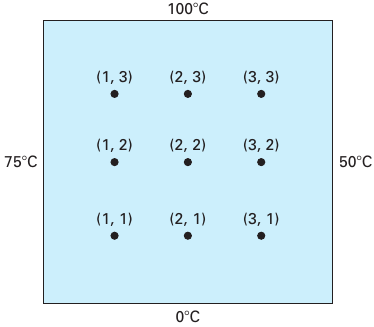

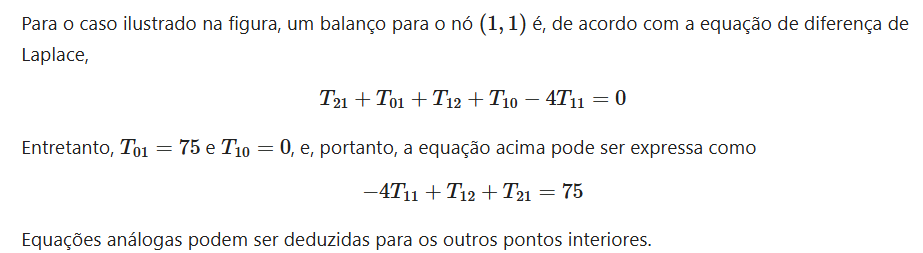

[[100 100 100 100 100 100 100 100 100 50]
 [75 T_{11} T_{12} T_{13} T_{14} T_{15} T_{16} T_{17} T_{18} 50]
 [75 T_{21} T_{22} T_{23} T_{24} T_{25} T_{26} T_{27} T_{28} 50]
 [75 T_{31} T_{32} T_{33} T_{34} T_{35} T_{36} T_{37} T_{38} 50]
 [75 T_{41} T_{42} T_{43} T_{44} T_{45} T_{46} T_{47} T_{48} 50]
 [75 T_{51} T_{52} T_{53} T_{54} T_{55} T_{56} T_{57} T_{58} 50]
 [75 T_{61} T_{62} T_{63} T_{64} T_{65} T_{66} T_{67} T_{68} 50]
 [75 T_{71} T_{72} T_{73} T_{74} T_{75} T_{76} T_{77} T_{78} 50]
 [75 T_{81} T_{82} T_{83} T_{84} T_{85} T_{86} T_{87} T_{88} 50]
 [0 0 0 0 0 0 0 0 0 50]]


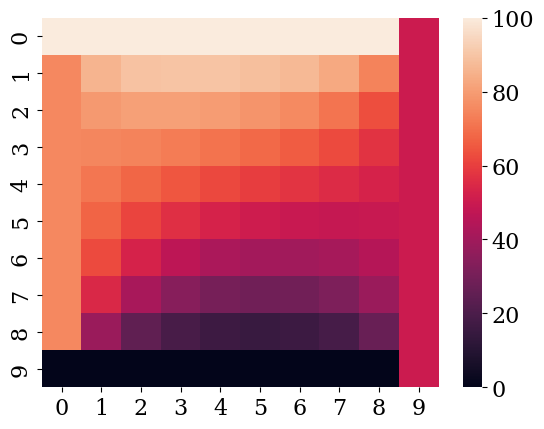

In [141]:
n = 10
variables = [sp.symbols('T_{'+str(i)+str(j)+'}') for i in range(n) for j in range(n)]
T = np.array([variables[i*n:i*n + n] for i in range(n)])

T[:, 0] = 75
T[0, :] = 100
T[n-1, :] = 0
T[:, n-1] = 50

print(T)

eqs = []
for i in range(1, n-1):
    for j in range(1, n-1):
        eq = T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1] - 4*T[i, j]
        eqs.append(eq)

        
variables_final =  [item for item in T.flatten() if isinstance(item, sp.core.symbol.Symbol)]
res = sp.solve(eqs, variables_final)
temps =np.array( [float(v) for v in res.values()])
##temps = np.array( [float(v) for v in list(res)[0]])
temps = temps.reshape(-1, n-2)
T[1:-1, 1:-1] = temps 
T = T.astype(float)


sns.heatmap( T )
plt.show()


O Método de Liebmann

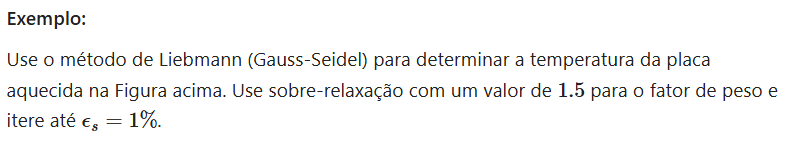

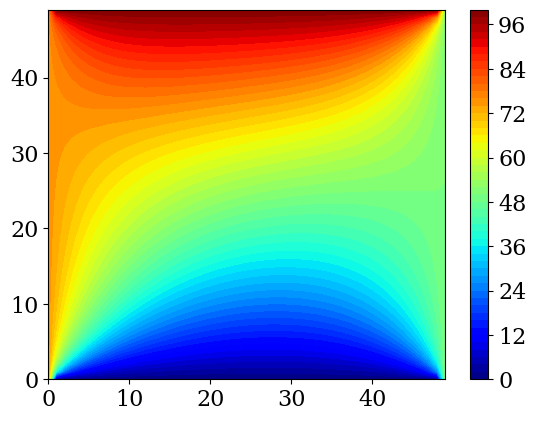

In [142]:
from numpy import meshgrid , arange , full , linalg

#Build a mesh
X , Y = np.meshgrid(np.arange (0 , 50) , np.arange (0 , 50) )

#Initialize
U0 = 30 # first guess
U= np.full ((50 , 50) , U0 , dtype = float )
V= np.full ((50 , 50) , U0 , dtype = float )
# Boundary contitions
Unorth = 100
Usouth = 0
Uwest = 75
Ueast = 50

U [49 ,:] = Unorth #Dirichlet
U [0 ,:] = Usouth #Dirichlet
U [: , 0] = Uwest #Dirichlet
U [: , 49:] = Ueast #Dirichlet
#U [: , 48:] = Ueast #Neumann


#Iteration settings
iteration =0
dxy = 1
imax = 10000

#Iterate
while iteration < imax :
    #
    # Calculate central point
    for i in range(1 , 49 , dxy ) :
        for j in range (1 , 49 , dxy ) :
            U [i , j ] = ( U [i -1 , j ]
            + U [ i +1 , j ]
            + U [i ,j -1]
            + U [i , j +1]) /4
    iteration +=1
    error = ( np.linalg.norm(U) - np.linalg.norm(V)) \
    / np.linalg.norm ( U )


    # V = U.copy()
    for i in range (0 ,50) :
        for j in range (0 ,50): 
            V[i][j]= U[i][j]

    if error < 0.0001: 
        iteration = imax


plt.contourf(X ,Y ,U , 60, cmap = plt.cm.jet )
#sns.heatmap(U)
plt.colorbar()
plt.show()


Condições de Contorno

## Diferenças Finitas: Equações Hiperbolicas


In [143]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 16

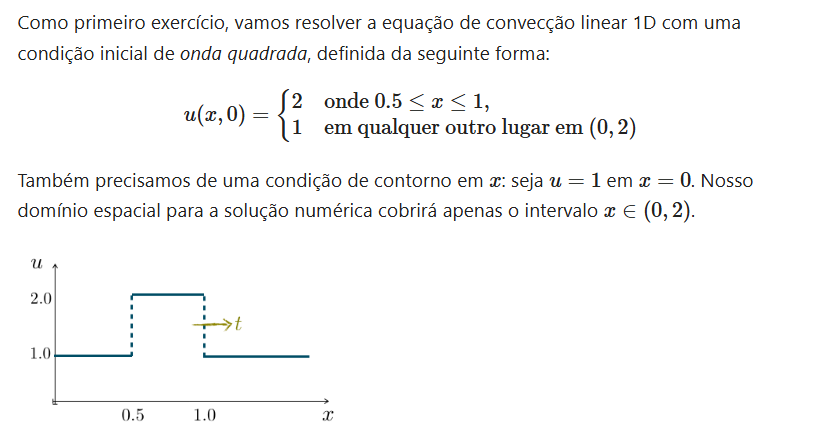

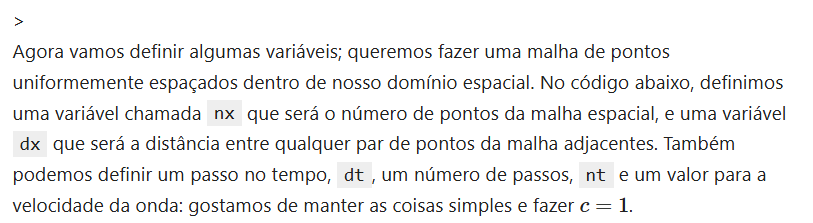

In [144]:
# Set parameters.
nx = 41  # number of spatial discrete points
L = 2.0  # length of the 1D domain
dx = L / (nx - 1)  # spatial grid size
nt = 25  # number of time steps
dt = 0.02  # time-step size
c = 1.0  # convection speed

# Define the grid point coordinates.
x = np.linspace(0.0, L, num=nx)

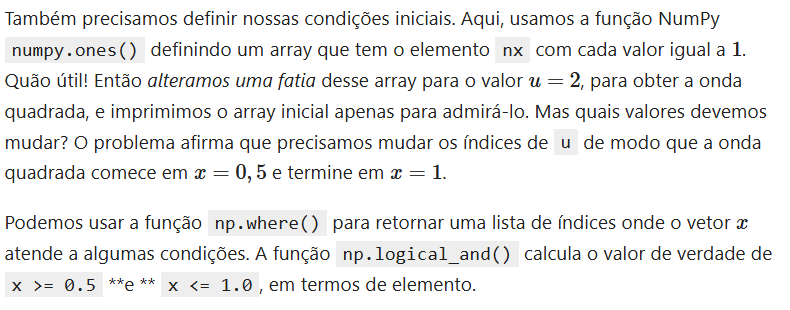

In [145]:

# Set initial conditions with 1.0 everywhere (for now).
u0 = np.ones(nx)
# Get a list of indices where 0.5 <= x <= 1.0.
mask = np.where(np.logical_and(x >= 0.5, x <= 1.0))
print(mask)

(array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]),)


Com a lista de índices, agora podemos atualizar nossas condições iniciais para obter uma forma de onda quadrada.

In [146]:
# Set initial condition u = 2.0 where 0.5 <= x <= 1.0.
u0[mask] = 2.0
print(u0)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Agora vamos dar uma olhada nessas condições iniciais que construímos com um gráfico útil.



(0.0, 2.5)

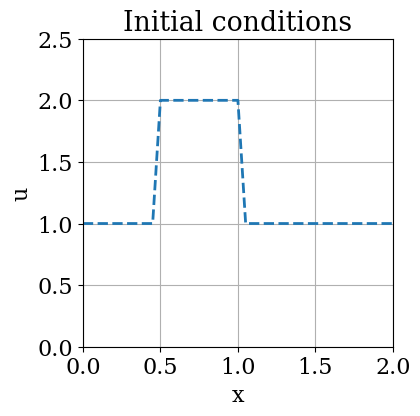

In [147]:
# Plot the initial conditions.
plt.figure(figsize=(4.0, 4.0))
plt.title('Initial conditions')
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
plt.plot(x, u0, color='C0', linestyle='--', linewidth=2)
plt.xlim(0.0, L)
plt.ylim(0.0, 2.5)

In [148]:
u = u0.copy()
for n in range(1, nt):
    un = u.copy()
    for i in range(1, nx):
        u[i] = un[i] - c * dt / dx * (un[i] - un[i - 1])

(0.0, 2.5)

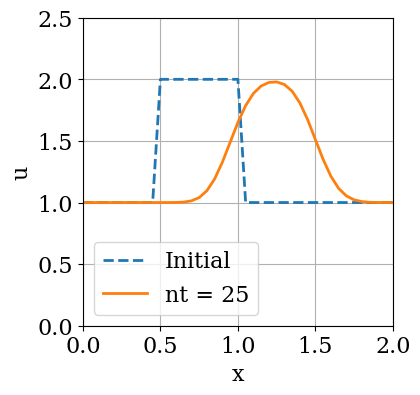

In [149]:
# Plot the solution after nt time steps
# along with the initial conditions.
plt.figure(figsize=(4.0, 4.0))
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
plt.plot(x, u0, label='Initial',
            color='C0', linestyle='--', linewidth=2)
plt.plot(x, u, label='nt = {}'.format(nt),
            color='C1', linestyle='-', linewidth=2)
plt.legend()
plt.xlim(0.0, L)
plt.ylim(0.0, 2.5)

Convecção Não-linear


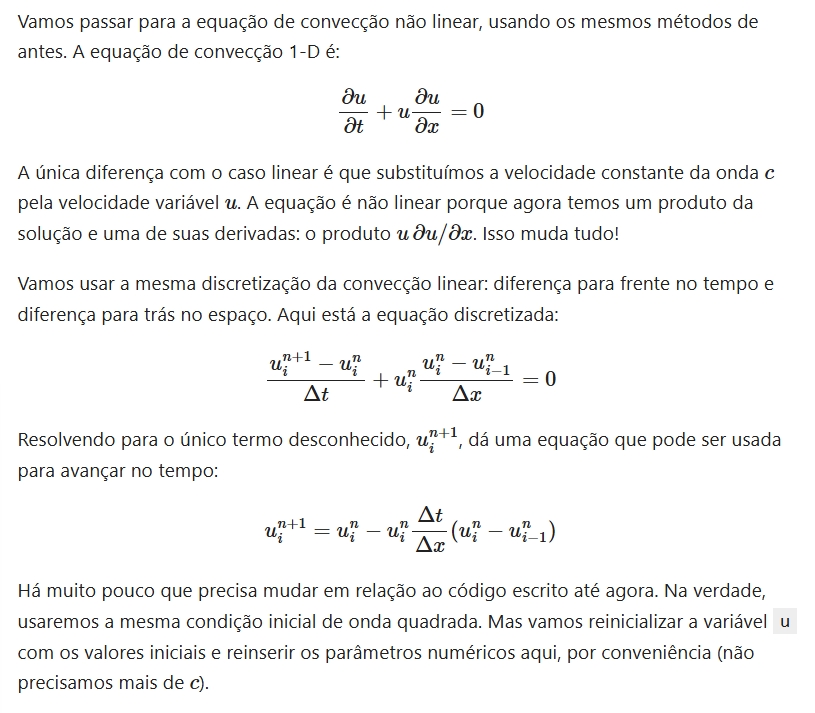

In [150]:

# Set parameters.
nx = 41  # number of spatial discrete points
L = 2.0  # length of the 1D domain
dx = L / (nx - 1)  # spatial grid size
nt = 10  # number of time steps
dt = 0.02  # time-step size

x = np.linspace(0.0, L, num=nx)
u0 = np.ones(nx)
mask = np.where(np.logical_and(x >= 0.5, x <= 1.0))
u0[mask] = 2.0

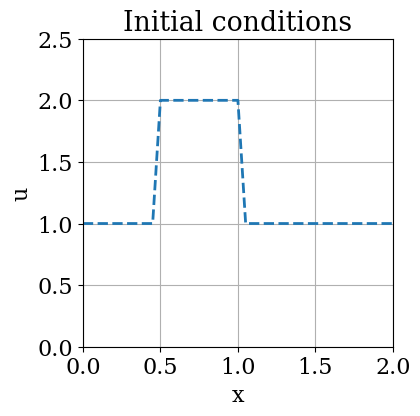

In [151]:
# Plot the initial conditions.
plt.figure(figsize=(4.0, 4.0))
plt.title('Initial conditions')
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
plt.plot(x, u0, color='C0', linestyle='--', linewidth=2)
plt.xlim(0.0, L)
plt.ylim(0.0, 2.5);

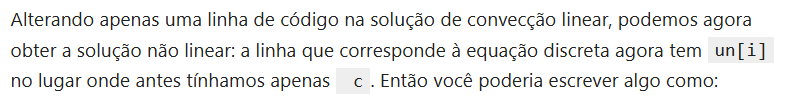

In [152]:
for n in range(1, nt):
   un = u.copy()
   for i in range(1, nx):
     u[i] = un[i] - un[i]*dt/dx*(un[i]-un[i-1])

In [153]:

# Compute the solution using Euler's method and array slicing.
u = u0.copy()
for n in range(1, nt):
    u[1:] = u[1:] - dt / dx * u[1:] * (u[1:] - u[:-1])

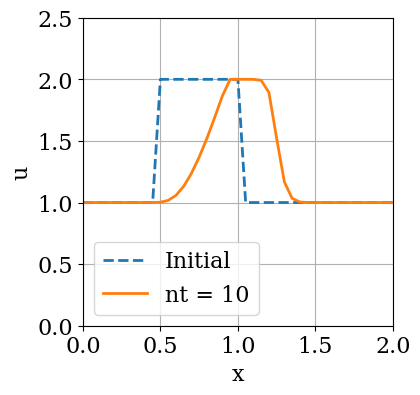

In [154]:

# Plot the solution after nt time steps
# along with the initial conditions.
plt.figure(figsize=(4.0, 4.0))
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
plt.plot(x, u0, label='Initial',
            color='C0', linestyle='--', linewidth=2)
plt.plot(x, u, label='nt = {}'.format(nt),
            color='C1', linestyle='-', linewidth=2)
plt.legend()
plt.xlim(0.0, L)
plt.ylim(0.0, 2.5);

In [155]:
def linear_convection_cfl(nx, L=2.0, c=1.0, sigma=0.5, nt=20):
    """
    Solves the 1D linear convection equation
    with constant speed c in the domain [0, L]
    and plots the solution (along with the initial conditions).
    Here, the time-step size is calculated based on a CFL constraint.

    Parameters
    ----------
    nx : integer
        Number of grid points to discretize the domain.
    L : float, optional
        Length of the domain; default: 2.0.
    c : float, optional
        Convection speed; default: 1.0.
    sigma : float, optional
        CFL constraint; default: 0.5.
    dt : float, optional
        Time-step size; default: 0.025.
    nt : integer, optional
        Number of time steps to compute; default: 20.
    """
    # Discretize spatial grid.
    dx = L / (nx - 1)
    x = np.linspace(0.0, L, num=nx)
    # Compute the time-step size based on the CFL constraint.
    dt = sigma * dx / c
    # Set initial conditions.
    u0 = np.ones(nx)
    mask = np.where(np.logical_and(x >= 0.5, x <= 1.0))
    u0[mask] = 2.0
    # Integrate the solution in time.
    u = u0.copy()
    for n in range(1, nt):
        u[1:] = u[1:] - c * dt / dx * (u[1:] - u[:-1])
    # Plot the solution along with the initial conditions.
    plt.figure(figsize=(4.0, 4.0))
    plt.xlabel('x')
    plt.ylabel('u')
    plt.grid()
    plt.plot(x, u0, label='Initial',
                color='C0', linestyle='--', linewidth=2)
    plt.plot(x, u, label='nt = {}'.format(nt),
                color='C1', linestyle='-', linewidth=2)
    plt.legend()
    plt.xlim(0.0, L)
    plt.ylim(0.0, 2.5);

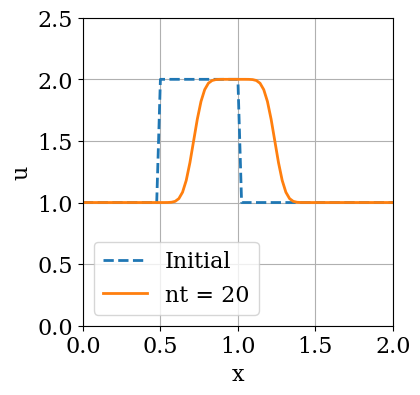

In [156]:
linear_convection_cfl(85)

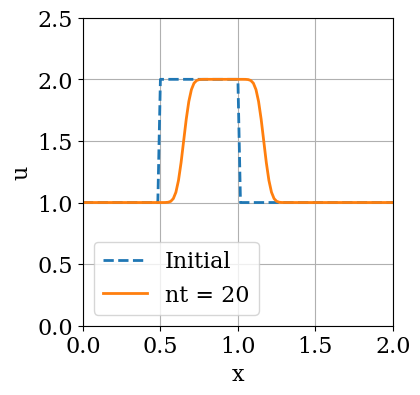

In [157]:
linear_convection_cfl(121)

## Difusão 1D

In [158]:

# Set parameters.
nx = 41  # number spatial grid points
L = 2.0  # length of the domain
dx = L / (nx - 1)  # spatial grid size
nu = 0.3  # viscosity
sigma = 0.2  # CFL limit
dt = sigma * dx**2 / nu  # time-step size
nt = 20  # number of time steps to compute

# Get the grid point coordinates.
x = np.linspace(0.0, L, num=nx)

# Set the initial conditions.
u0 = np.ones(nx)
mask = np.where(np.logical_and(x >= 0.5, x <= 1.0))
u0[mask] = 2.0

In [159]:
# Integrate in time.
u = u0.copy()
for n in range(nt):
    u[1:-1] = u[1:-1] + nu * dt / dx**2 * (u[2:] - 2 * u[1:-1] + u[:-2])


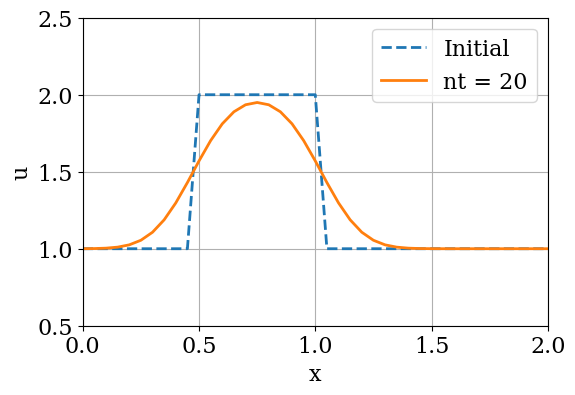

In [160]:

# Plot the solution after nt time steps
# along with the initial conditions.
plt.figure(figsize=(6.0, 4.0))
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
plt.plot(x, u0, label='Initial',
            color='C0', linestyle='--', linewidth=2)
plt.plot(x, u, label='nt = {}'.format(nt),
            color='C1', linestyle='-', linewidth=2)
plt.legend(loc='upper right')
plt.xlim(0.0, L)
plt.ylim(0.5, 2.5);

## Metodo das Linhas

In [161]:
alpha = 0.01
h = 0.1
T_a = 25.
T_ini = 25.
T_ext = 100.
L = 1.
N = 6
dx = L/(N - 1)
dt = 0.01

duration = 12000
t_eval = np.linspace(0, duration, 1000)

Usando o metodo de Euler

In [162]:
def euler(func, ti, yi, h=1):
    return yi + func(ti, yi) * h


In [163]:
alpha = 0.01
h = 0.1
T_a = 25.
T_ini = 25.
T_ext = 100.
L = 1.
N = 6
dx = L/(N - 1)
dt = 0.01

duration = int(120 / dt)
t_eval = np.linspace(0, duration, 1000)

In [164]:
def _Euler(Tt, h = dt):
  
    Tt[0] = T_ext
    Tt[-1] = Tt[-2]
    n = len(Tt) - 1

    for i in range(1, n):
        Tt[i] = Tt[i] + h*(alpha * (Tt[i + 1] - 2 * Tt[i] + Tt[i - 1]) / dx ** 2 - h * alpha * (Tt[i] - T_a))
        
        #print(Tt)

    # enforce boundary conditions
    Tt[0] = T_ext
    Tt[-1] = Tt[-2]

    return Tt

In [165]:
T0 = np.ones(N) * T_ini

# boundary conditions
T0[0] = T_ext
T0[-1] = T0[-2]

Tts = [T0.copy()]

for _ in range(1, duration):
    Tts.append(_Euler(Tts[-1]).copy())

Tts = np.array(Tts)

In [166]:
Tts.shape

(12000, 6)

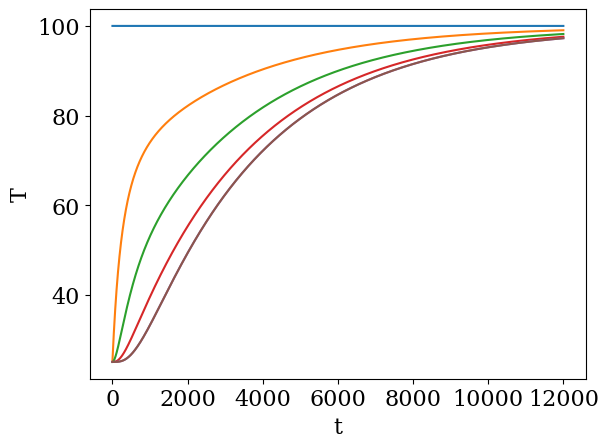

In [167]:
t = np.linspace(0, duration, duration)

plt.plot(t, Tts);
plt.xlabel('t')
plt.ylabel('T'); 